In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

from fhd.structure_factor import structure_factor

DATA_ROOT = Path("data_smoke")


REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

In [2]:

RUN_RE = re.compile(r"VS_run_(\d+)_Dv(\d+)_.*\.npz$")


def find_runs(regime, target_Dv):
    """
    Find all NPZ files for a regime whose stored D_v matches target_Dv.

    We select by the D_v stored inside the file rather than by Dv index.
    This means the same plotting script works for:

        local test: DV_VALS = [0.01, 0.20]
        full sweep: DV_VALS = linspace(0.01, 0.20, 20)
    """
    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing regime directory: {regime_dir}"
        )

    matches = []

    for path in sorted(regime_dir.glob("VS_run_*_Dv*_*.npz")):
        with np.load(path, allow_pickle=False) as z:
            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            matches.append(path)

    if not matches:
        raise FileNotFoundError(
            f"No files found for regime={regime}, D_v={target_Dv}"
        )

    # Check that each run appears only once.
    run_indices = []

    for path in matches:
        match = RUN_RE.match(path.name)
        if match is None:
            raise RuntimeError(
                f"Could not parse run index from {path.name}"
            )

        run_indices.append(int(match.group(1)))

    if len(run_indices) != len(set(run_indices)):
        raise RuntimeError(
            f"Duplicate run indices for {regime}, D_v={target_Dv}: "
            f"{run_indices}"
        )


    return matches


In [3]:
path_to_runs = find_runs("segregating", 0.2)
data1 = np.load(path_to_runs[1])


In [4]:
list(data1)

['frame_index',
 'frame_step',
 'time',
 'mean_A',
 'mean_B',
 'mean_0',
 'mean_pol',
 'mean_occ',
 'var_A',
 'var_B',
 'var_0',
 'var_pol',
 'var_occ',
 'dissimilarity',
 'relative_entropy',
 'k_mean_pol',
 'interface_density',
 'k_centers',
 'k_edges',
 'spectrum_counts',
 'spectrum_use_lattice_k',
 'spectrum_dct_type',
 'spectrum_centered',
 'S_AA',
 'S_BB',
 'S_00',
 'S_AB',
 'S_A0',
 'S_B0',
 'S_pol',
 'S_occ',
 'phi_final',
 'tail_frame_indices',
 'tail_time_start',
 'tail_nframes',
 'dissimilarity_tail_mean',
 'dissimilarity_tail_std',
 'relative_entropy_tail_mean',
 'relative_entropy_tail_std',
 'k_mean_pol_tail_mean',
 'k_mean_pol_tail_std',
 'interface_density_tail_mean',
 'interface_density_tail_std',
 'S_AA_tail_mean',
 'S_AA_tail_std',
 'S_BB_tail_mean',
 'S_BB_tail_std',
 'S_00_tail_mean',
 'S_00_tail_std',
 'S_AB_tail_mean',
 'S_AB_tail_std',
 'S_A0_tail_mean',
 'S_A0_tail_std',
 'S_B0_tail_mean',
 'S_B0_tail_std',
 'S_pol_tail_mean',
 'S_pol_tail_std',
 'S_occ_tail_mean

In [5]:
data1['proj_hist_mass_redistributed_low_local']

array([0.00000000e+00, 0.00000000e+00, 8.22528114e-03, ...,
       2.57994119e+03, 2.58253099e+03, 2.58253099e+03], shape=(2000,))

In [6]:
data1["proj_mass_redistributed_low_local"]

array(2582.53098597)

In [7]:
data1["proj_mass_redistributed_low_local"]/(128*128*0.7)

np.float64(0.22517883178472894)

In [8]:
data1['time']

array([ 0.  ,  0.05,  0.1 , ..., 49.9 , 49.95, 50.  ], shape=(1001,))

# Dissimilary vs D_V

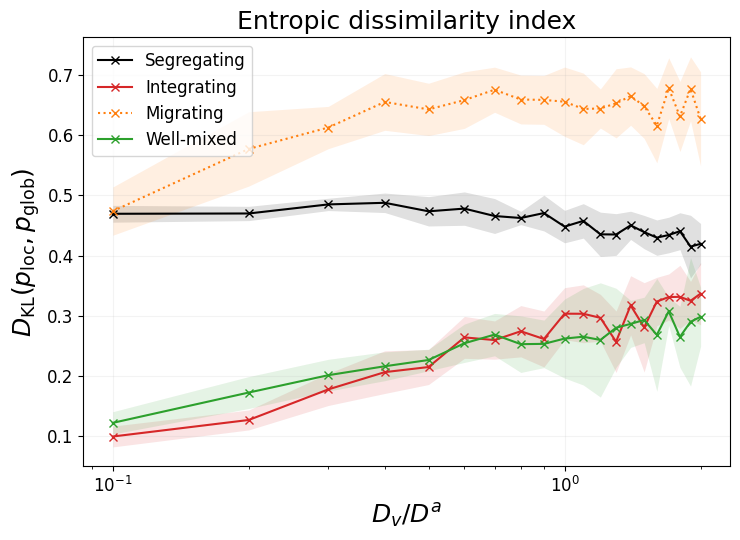

In [40]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_LABELS = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}

# Snellius sweep:
# D_v = 0.01, 0.02, ..., 0.20
DV_VALUES = np.round(
    np.arange(0.01, 0.201, 0.01),
    2,
)

EXPECTED_NRUNS = 10

# Schelling diffusion coefficient
D = np.array([0.1, 0.1])


# =============================================================================
# Find files for one regime / D_v
# =============================================================================

def find_runs(regime, target_Dv):

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    paths = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            paths.append(path)

    if (
        EXPECTED_NRUNS is not None
        and len(paths) != EXPECTED_NRUNS
    ):
        raise RuntimeError(
            f"{regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS} runs, "
            f"found {len(paths)}"
        )

    return paths


# =============================================================================
# Ensemble average of last-200-frame relative entropy
# =============================================================================

means = {
    regime: []
    for regime in REGIMES
}

stds = {
    regime: []
    for regime in REGIMES
}


for regime in REGIMES:

    for Dv in DV_VALUES:

        paths = find_runs(
            regime,
            Dv,
        )

        run_tail_means = []

        for path in paths:

            with np.load(
                path,
                allow_pickle=False,
            ) as z:

                # -----------------------------------------------------
                # Preferred: use precomputed last-200-frame average
                # -----------------------------------------------------

                if "relative_entropy_tail_mean" in z.files:

                    value = float(
                        z["relative_entropy_tail_mean"]
                    )

                # -----------------------------------------------------
                # Fallback: explicitly calculate last 200 frames
                # -----------------------------------------------------

                else:

                    relative_entropy = (
                        z["relative_entropy"]
                    )

                    value = float(
                        np.mean(
                            relative_entropy[-200:]
                        )
                    )

                run_tail_means.append(
                    value
                )

        run_tail_means = np.asarray(
            run_tail_means
        )

        # Mean over independent runs
        means[regime].append(
            np.mean(
                run_tail_means
            )
        )

        # Run-to-run standard deviation
        stds[regime].append(
            np.std(
                run_tail_means,
                ddof=1,
            )
        )


for regime in REGIMES:

    means[regime] = np.asarray(
        means[regime]
    )

    stds[regime] = np.asarray(
        stds[regime]
    )


# =============================================================================
# Plot
# =============================================================================

x = DV_VALUES / D[0]


fig, ax = plt.subplots(
    figsize=(7.5, 5.5)
)


# Segregating
ax.semilogx(
    x,
    means["segregating"],
    "x-",
    color="black",
    label="Segregating",
)

# Integrating
ax.semilogx(
    x,
    means["integrating"],
    "x-",
    color="tab:red",
    label="Integrating",
)

# Migrating
ax.semilogx(
    x,
    means["migrating"],
    "x:",
    color="tab:orange",
    label="Migrating",
)

# Well-mixed
ax.semilogx(
    x,
    means["well-mixed"],
    "x-",
    color="tab:green",
    label="Well-mixed",
)


# =============================================================================
# Optional: run-to-run standard deviation
# =============================================================================

SHOW_STD = True

if SHOW_STD:

    colors = {
        "segregating": "black",
        "integrating": "tab:red",
        "migrating": "tab:orange",
        "well-mixed": "tab:green",
    }

    for regime in REGIMES:

        mean = means[regime]
        std = stds[regime]

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            color=colors[regime],
            alpha=0.12,
            linewidth=0,
        )


# =============================================================================
# Formatting
# =============================================================================

ax.set_xlabel(
    r"$D_v/D^a$",
    fontsize=18,
)

ax.set_ylabel(
    r"$D_{\rm KL}(p_{\rm loc},p_{\rm glob})$",
    fontsize=18,
)

ax.set_title(
    "Entropic dissimilarity index",
    fontsize=18,
)

ax.tick_params(
    axis="both",
    labelsize=12,
)

ax.legend(
    fontsize=12,
)

ax.grid(
    alpha=0.15,
)

fig.tight_layout()

plt.show()

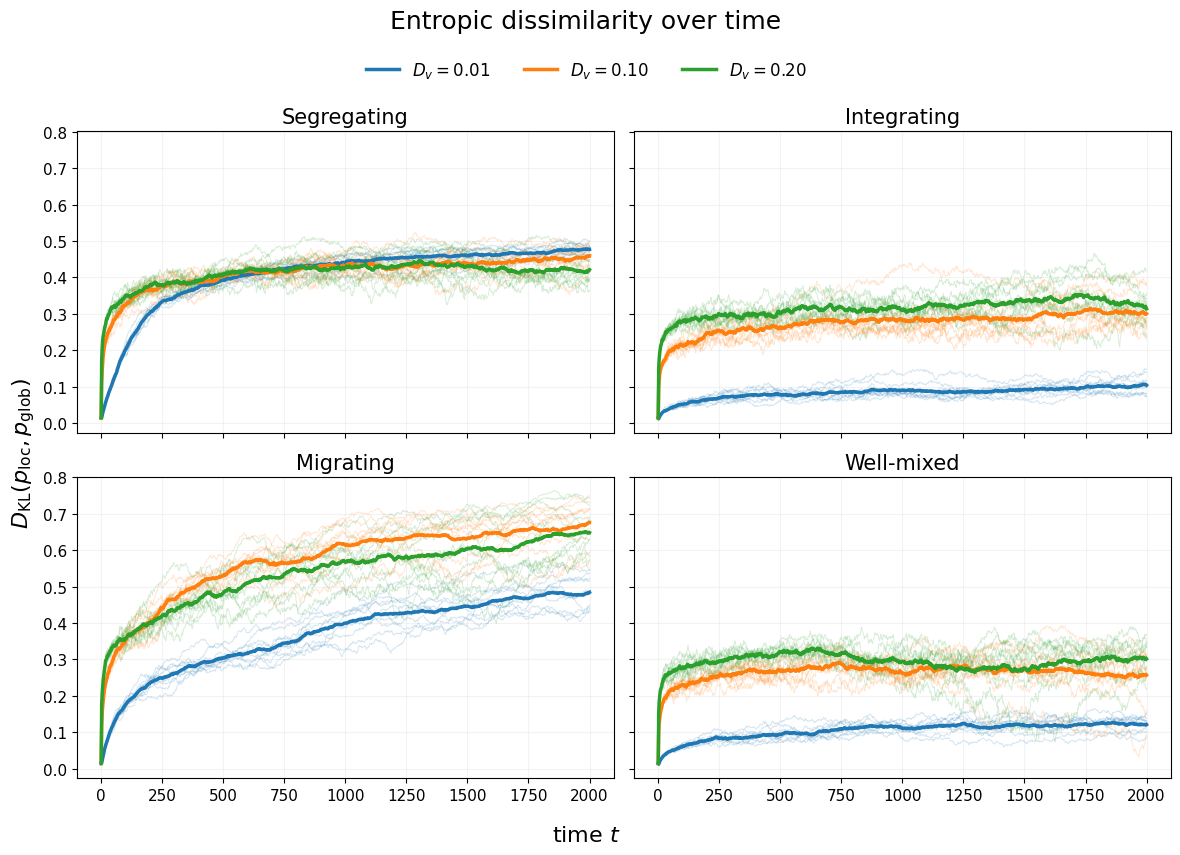

In [2]:
# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_TITLES = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}

DV_VALUES = (
    0.01,
    0.10,
    0.20,
)

EXPECTED_NRUNS = 10

# Visual styling
COLORS = {
    0.01: "tab:blue",
    0.10: "tab:orange",
    0.20: "tab:green",
}

RUN_ALPHA = 0.18
RUN_LINEWIDTH = 0.7
MEAN_LINEWIDTH = 2.5


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def run_index_from_path(path):

    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):
    """
    Find all runs for one regime and D_v.
    """

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():

        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    paths = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(
                z["D_v"]
            )

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):

            paths.append(path)


    paths = sorted(
        paths,
        key=run_index_from_path,
    )


    if (
        EXPECTED_NRUNS is not None
        and len(paths) != EXPECTED_NRUNS
    ):

        raise RuntimeError(
            f"{regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS} runs, "
            f"found {len(paths)}"
        )

    return paths


# =============================================================================
# Load ensemble
# =============================================================================

def load_entropy_ensemble(
    regime,
    target_Dv,
):
    """
    Returns
    -------
    time : ndarray, shape (ntime,)

    entropy_runs : ndarray, shape (nruns, ntime)
        Entropic dissimilarity / relative entropy for every run.
    """

    paths = find_runs(
        regime,
        target_Dv,
    )

    time_reference = None

    entropy_runs = []

    for path in paths:

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            time = (
                z["time"]
                .astype(float)
            )

            entropy = (
                z["relative_entropy"]
                .astype(float)
            )


        if time_reference is None:

            time_reference = time

        else:

            if (
                len(time) != len(time_reference)
                or not np.allclose(
                    time,
                    time_reference,
                )
            ):

                raise RuntimeError(
                    f"Time grid mismatch in {path}"
                )


        if len(entropy) != len(time):

            raise RuntimeError(
                f"Observable/time length mismatch "
                f"in {path}"
            )


        entropy_runs.append(
            entropy
        )


    entropy_runs = np.stack(
        entropy_runs,
        axis=0,
    )

    return (
        time_reference,
        entropy_runs,
    )


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()


for ax, regime in zip(
    axes,
    REGIMES,
):

    for Dv in DV_VALUES:

        time, runs = (
            load_entropy_ensemble(
                regime,
                Dv,
            )
        )

        color = COLORS[Dv]


        # =============================================================
        # Individual runs
        # =============================================================

        for run in runs:

            ax.plot(
                time,
                run,
                color=color,
                linewidth=RUN_LINEWIDTH,
                alpha=RUN_ALPHA,
                zorder=1,
            )


        # =============================================================
        # Ensemble mean
        # =============================================================

        mean = np.mean(
            runs,
            axis=0,
        )

        ax.plot(
            time,
            mean,
            color=color,
            linewidth=MEAN_LINEWIDTH,
            label=fr"$D_v={Dv:.2f}$",
            zorder=3,
        )


    # -----------------------------------------------------------------
    # Panel formatting
    # -----------------------------------------------------------------

    ax.set_title(
        REGIME_TITLES[regime],
        fontsize=15,
    )

    ax.grid(
        alpha=0.15,
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
    )


# =============================================================================
# Shared labels
# =============================================================================

fig.supxlabel(
    r"time $t$",
    fontsize=16,
)

fig.supylabel(
    r"$D_{\rm KL}(p_{\rm loc},p_{\rm glob})$",
    fontsize=16,
)


# =============================================================================
# One shared legend
# =============================================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    fontsize=12,
    frameon=False,
)


fig.suptitle(
    "Entropic dissimilarity over time",
    fontsize=18,
    y=1.055,
)


fig.tight_layout()

plt.show()

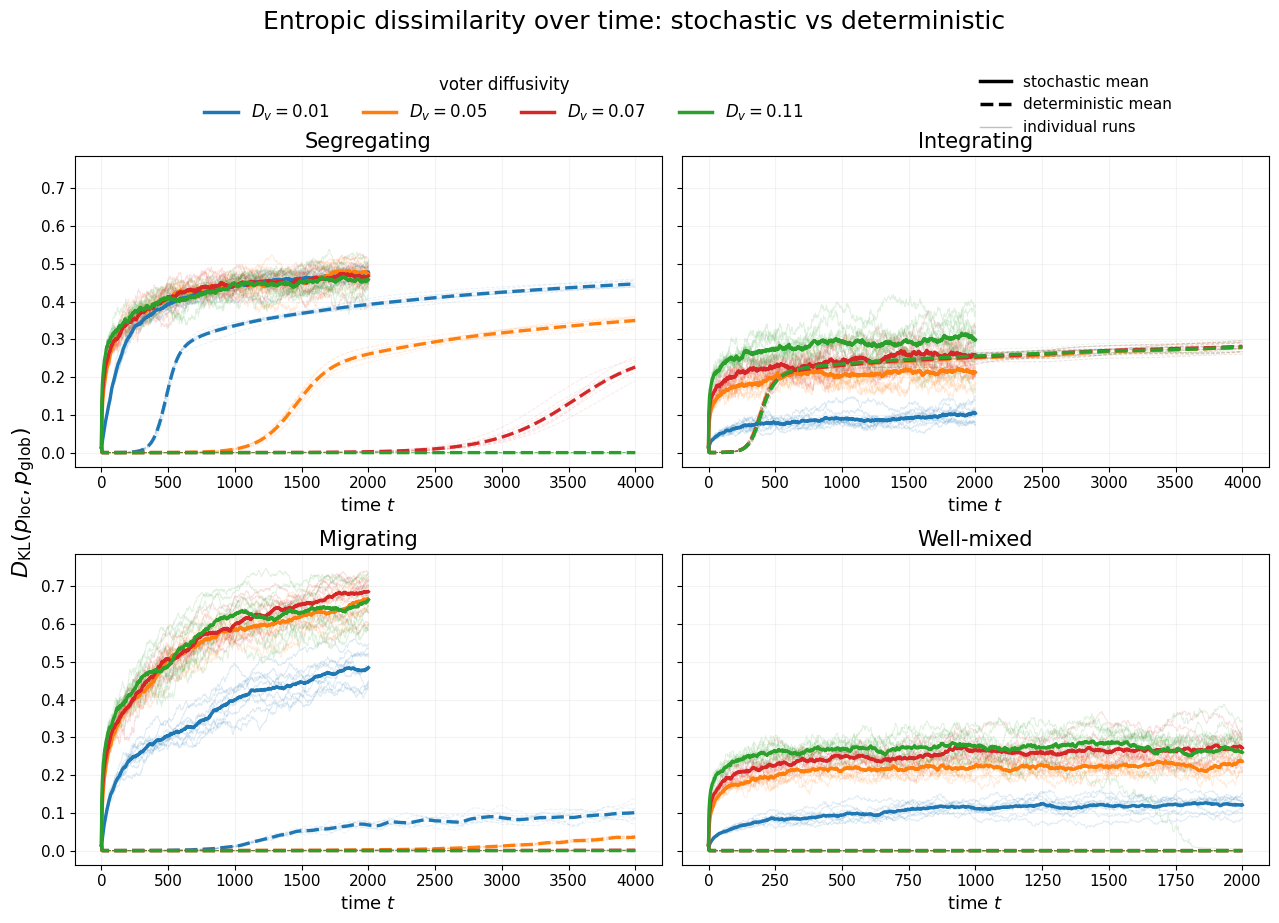

In [9]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# Configuration
# =============================================================================

# -----------------------------
# Stochastic (Snellius) data
# -----------------------------
DATA_ROOT_STOCH = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_TITLES = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}

DV_VALUES = (0.01, 0.05, 0.07, 0.11)

EXPECTED_NRUNS_STOCH = 10
EXPECTED_NRUNS_DET = 10

# -----------------------------
# Deterministic timing
# -----------------------------
DT = 1e-3
NSTEPS_DET = 4_000_000          # for segregating / integrating / migrating
NSTEPS_DET_WM = 2_000_000       # for well-mixed
NFRAMES_DET = 800              # number used in t = dt * nsteps * snapshot / frames

# -----------------------------
# Plot styling
# -----------------------------
COLORS = {
    0.01: "tab:blue",
    0.05: "tab:orange",
    0.07: "tab:red",
    0.11: "tab:green",
}

STOCH_RUN_ALPHA = 0.14
DET_RUN_ALPHA = 0.10

STOCH_RUN_LW = 0.7
DET_RUN_LW = 0.7

STOCH_MEAN_LW = 2.4
DET_MEAN_LW = 2.4

SHOW_STOCH_RUNS = True
SHOW_DET_RUNS = True

USE_LOG_TIME = False   # set True if you want logarithmic time axis


# =============================================================================
# Deterministic data loading
# =============================================================================
# Assumes you already executed something like:
#
df = pd.read_csv("processed_det_run2/masses_per_run.csv")
# df_mpp = pd.read_csv("processed_det_run2/masses_by_parameter.csv")
# df_obs = pd.read_csv("processed_det_run2/observables_spectra_per_run.csv")
# df_obs_bp = pd.read_csv("processed_det_run2/observables_spectra_by_parameter.csv")

df_wm = pd.read_csv("processed_deterministic/masses_per_run.csv")
# df_mpp_wm = pd.read_csv("processed_deterministic/masses_by_parameter.csv")
# df_obs_wm = pd.read_csv("processed_deterministic/observables_spectra_per_run.csv")
# df_obs_bp_wm = pd.read_csv("processed_deterministic/observables_spectra_by_parameter.csv")

df = pd.concat([df, df_wm[df_wm["regime"] == "well-mixed"]])
# df_mpp = pd.concat([df_mpp, df_mpp_wm[df_mpp_wm["regime"] == "well-mixed"]])
# df_obs = pd.concat([df_obs, df_obs_wm[df_obs_wm["regime"] == "well-mixed"]])
# df_obs_bp = pd.concat([df_obs_bp, df_obs_bp_wm[df_obs_bp_wm["regime"] == "well-mixed"]])
#
# Only df is actually needed below.
# =============================================================================


# =============================================================================
# Helpers: stochastic files
# =============================================================================

RUN_RE = re.compile(r"VS_run_(\d+)_Dv(\d+)_.*\.npz$")


def run_index_from_path(path):
    match = RUN_RE.match(path.name)
    if match is None:
        return -1
    return int(match.group(1))


def find_stochastic_runs(regime, target_Dv):
    regime_dir = DATA_ROOT_STOCH / regime

    if not regime_dir.exists():
        raise FileNotFoundError(f"Missing directory: {regime_dir}")

    paths = []

    for path in sorted(regime_dir.glob("VS_run_*_Dv*_*.npz")):
        with np.load(path, allow_pickle=False) as z:
            Dv_file = float(z["D_v"])

        if np.isclose(Dv_file, target_Dv, rtol=0.0, atol=1e-12):
            paths.append(path)

    paths = sorted(paths, key=run_index_from_path)

    if EXPECTED_NRUNS_STOCH is not None and len(paths) != EXPECTED_NRUNS_STOCH:
        raise RuntimeError(
            f"{regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS_STOCH} stochastic runs, found {len(paths)}"
        )

    return paths


def load_stochastic_entropy_ensemble(regime, target_Dv):
    """
    Returns
    -------
    time : ndarray, shape (ntime,)
    runs : ndarray, shape (nruns, ntime)
        relative_entropy for each stochastic run
    """
    paths = find_stochastic_runs(regime, target_Dv)

    time_ref = None
    runs = []

    for path in paths:
        with np.load(path, allow_pickle=False) as z:
            time = z["time"].astype(float)
            entropy = z["relative_entropy"].astype(float)

        if time_ref is None:
            time_ref = time
        else:
            if len(time) != len(time_ref) or not np.allclose(time, time_ref):
                raise RuntimeError(f"Time mismatch in stochastic file {path}")

        if len(entropy) != len(time):
            raise RuntimeError(f"Observable/time length mismatch in {path}")

        runs.append(entropy)

    runs = np.stack(runs, axis=0)
    return time_ref, runs


# =============================================================================
# Helpers: deterministic data
# =============================================================================

def deterministic_time_from_snapshot(snapshot, regime):
    """
    Reconstruct time from snapshot index using your previous convention:
        t = dt * nsteps * snapshot / frames
    """
    if regime == "well-mixed":
        nsteps = NSTEPS_DET_WM
    else:
        nsteps = NSTEPS_DET

    return DT * nsteps * np.asarray(snapshot) / NFRAMES_DET


def load_deterministic_entropy_ensemble(df, regime, target_Dv):
    """
    Returns
    -------
    time : ndarray, shape (ntime,)
    runs : ndarray, shape (nruns, ntime)
        DKL time series for each deterministic run
    """
    data = df[
        (df["regime"] == regime)
        & (np.isclose(df["D_v"], target_Dv, rtol=0.0, atol=1e-12))
    ].copy()

    if len(data) == 0:
        raise RuntimeError(
            f"No deterministic data found for regime={regime}, D_v={target_Dv}"
        )

    if "n_run" not in data.columns:
        raise KeyError("Expected deterministic dataframe to contain column 'n_run'")

    if "snapshot" not in data.columns:
        raise KeyError("Expected deterministic dataframe to contain column 'snapshot'")

    if "DKL" not in data.columns:
        raise KeyError("Expected deterministic dataframe to contain column 'DKL'")

    run_ids = sorted(data["n_run"].unique())

    if EXPECTED_NRUNS_DET is not None and len(run_ids) != EXPECTED_NRUNS_DET:
        print(
            f"WARNING: {regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS_DET} deterministic runs, found {len(run_ids)}"
        )

    time_ref = None
    runs = []

    for run_id in run_ids:
        sub = data[data["n_run"] == run_id].copy()
        sub = sub.sort_values("snapshot")

        time = deterministic_time_from_snapshot(
            sub["snapshot"].to_numpy(),
            regime,
        )

        dkl = sub["DKL"].to_numpy(dtype=float)

        if time_ref is None:
            time_ref = time
        else:
            if len(time) != len(time_ref) or not np.allclose(time, time_ref):
                raise RuntimeError(
                    f"Time mismatch in deterministic data for "
                    f"regime={regime}, D_v={target_Dv}, run={run_id}"
                )

        runs.append(dkl)

    runs = np.stack(runs, axis=0)
    return time_ref, runs


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13, 8.5),
    sharex=False,
    sharey=True,
)

axes = axes.ravel()

for ax, regime in zip(axes, REGIMES):

    for Dv in DV_VALUES:

        color = COLORS[Dv]

        # -------------------------------------------------------------
        # Stochastic
        # -------------------------------------------------------------
        t_st, runs_st = load_stochastic_entropy_ensemble(regime, Dv)
        mean_st = np.nanmean(runs_st, axis=0)

        if SHOW_STOCH_RUNS:
            for run in runs_st:
                valid = np.isfinite(run)
                ax.plot(
                    t_st[valid],
                    run[valid],
                    color=color,
                    alpha=STOCH_RUN_ALPHA,
                    linewidth=STOCH_RUN_LW,
                    linestyle="-",
                    zorder=1,
                )

        ax.plot(
            t_st,
            mean_st,
            color=color,
            linewidth=STOCH_MEAN_LW,
            linestyle="-",
            zorder=4,
        )

        # -------------------------------------------------------------
        # Deterministic
        # -------------------------------------------------------------
        t_det, runs_det = load_deterministic_entropy_ensemble(df, regime, Dv)
        mean_det = np.nanmean(runs_det, axis=0)

        if SHOW_DET_RUNS:
            for run in runs_det:
                valid = np.isfinite(run)
                ax.plot(
                    t_det[valid],
                    run[valid],
                    color=color,
                    alpha=DET_RUN_ALPHA,
                    linewidth=DET_RUN_LW,
                    linestyle="--",
                    zorder=2,
                )

        valid_mean_det = np.isfinite(mean_det)
        ax.plot(
            t_det[valid_mean_det],
            mean_det[valid_mean_det],
            color=color,
            linewidth=DET_MEAN_LW,
            linestyle="--",
            zorder=5,
        )

    # -------------------------------------------------------------
    # Panel formatting
    # -------------------------------------------------------------
    ax.set_title(REGIME_TITLES[regime], fontsize=15)
    ax.grid(alpha=0.15)
    ax.tick_params(axis="both", labelsize=11)

    if USE_LOG_TIME:
        ax.set_xscale("log")

    ax.set_xlabel(r"time $t$", fontsize=13)

# Shared y-label
fig.supylabel(
    r"$D_{\rm KL}(p_{\rm loc}, p_{\rm glob})$",
    fontsize=16,
)

# =============================================================================
# Legends
# =============================================================================

# Legend 1: colors = D_v
color_handles = [
    Line2D(
        [0], [0],
        color=COLORS[Dv],
        lw=2.5,
        linestyle="-",
        label=fr"$D_v={Dv:.2f}$",
    )
    for Dv in DV_VALUES
]

# Legend 2: linestyle = stochastic / deterministic
style_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.5,
        linestyle="-",
        label="stochastic mean",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2.5,
        linestyle="--",
        label="deterministic mean",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=1.0,
        alpha=0.25,
        linestyle="-",
        label="individual runs",
    ),
]

fig.legend(
    handles=color_handles,
    loc="upper center",
    bbox_to_anchor=(0.40, 1.02),
    ncol=4,
    frameon=False,
    fontsize=12,
    title=r"voter diffusivity",
    title_fontsize=12,
)

fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.84, 1.02),
    ncol=1,
    frameon=False,
    fontsize=11,
)

fig.suptitle(
    "Entropic dissimilarity over time: stochastic vs deterministic",
    fontsize=18,
    y=1.08,
)

fig.tight_layout()
plt.show()

# Configurations

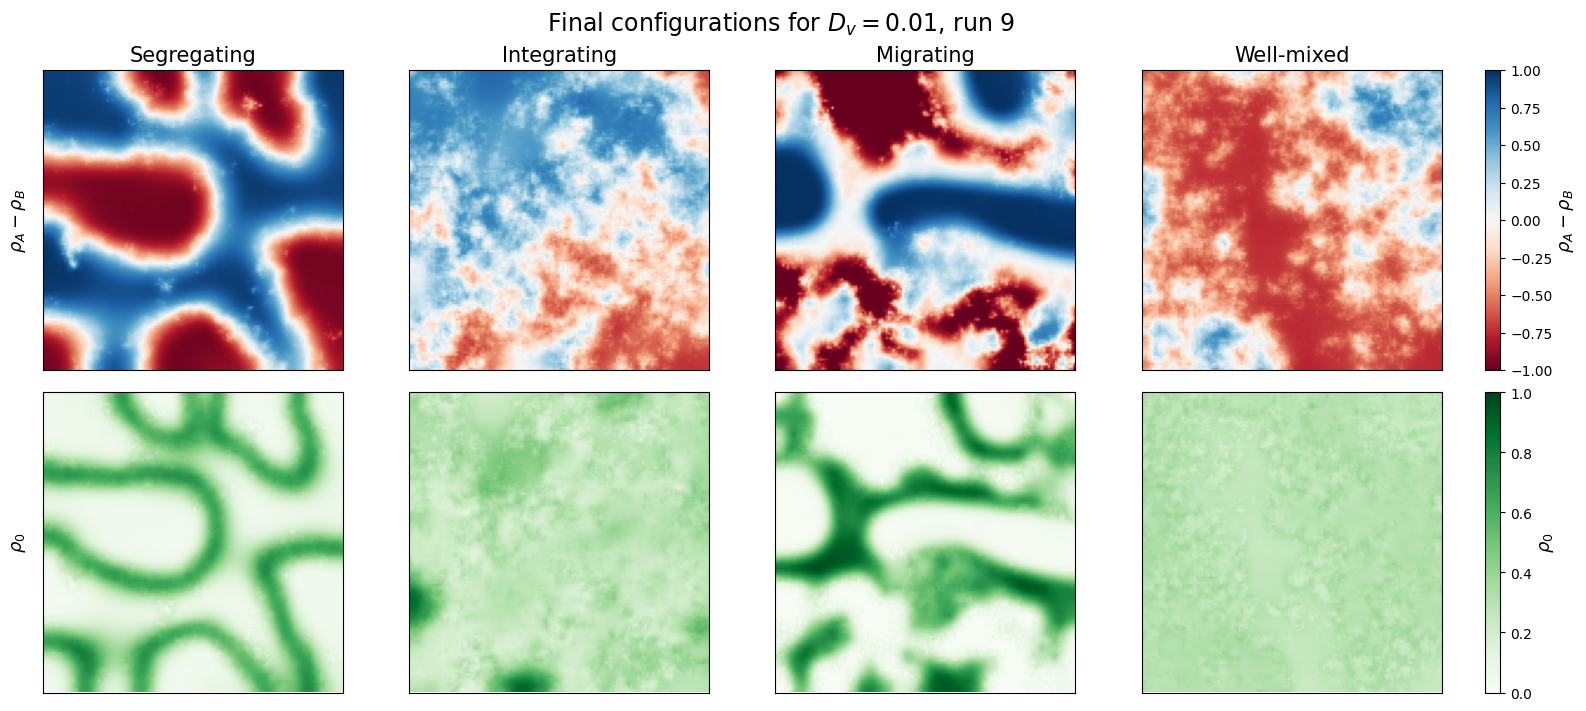

In [25]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_TITLES = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}

# Select parameter setting
D_V_TARGET = 0.01
RUN_INDEX = 9

# Color limits
POL_VMIN = -1.0
POL_VMAX = 1.0

RHO0_VMIN = 0.0
RHO0_VMAX = 1.0

# Figure style
TITLE_FS = 15
LABEL_FS = 13
TICK_FS = 11


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def run_index_from_path(path):
    match = RUN_RE.match(path.name)
    if match is None:
        return -1
    return int(match.group(1))


def find_file(regime, target_Dv, run_index):
    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    candidates = []

    for path in sorted(regime_dir.glob("VS_run_*_Dv*_*.npz")):
        this_run = run_index_from_path(path)

        if this_run != run_index:
            continue

        with np.load(path, allow_pickle=False) as z:
            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            candidates.append(path)

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No file found for regime={regime}, "
            f"D_v={target_Dv}, run={run_index}"
        )

    if len(candidates) > 1:
        raise RuntimeError(
            f"Multiple files found for regime={regime}, "
            f"D_v={target_Dv}, run={run_index}: {candidates}"
        )

    return candidates[0]


# =============================================================================
# Load one final configuration
# =============================================================================

def load_final_fields(path):
    with np.load(path, allow_pickle=False) as z:
        phi = z["phi_final"].astype(float)
        h = float(z["h"])

    rhoA = phi[0]
    rhoB = phi[1]

    m = rhoA - rhoB
    rho0 = 1.0 - rhoA - rhoB

    Nx, Ny = rhoA.shape

    Lx = Nx * h
    Ly = Ny * h

    extent = [-Lx / 2, Lx / 2, -Ly / 2, Ly / 2]

    return m, rho0, extent


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(16, 7),
    constrained_layout=True,
)

im_pol = None
im_rho0 = None

for col, regime in enumerate(REGIMES):

    path = find_file(
        regime=regime,
        target_Dv=D_V_TARGET,
        run_index=RUN_INDEX,
    )

    m, rho0, extent = load_final_fields(path)

    # -----------------------------------------------------------------
    # Polarization mode
    # -----------------------------------------------------------------
    ax = axes[0, col]

    im_pol = ax.imshow(
        m,
        cmap="RdBu",
        aspect="equal",
        origin="lower",
        extent=extent,
        vmin=POL_VMIN,
        vmax=POL_VMAX,
    )

    ax.set_title(
        REGIME_TITLES[regime],
        fontsize=TITLE_FS,
    )

    # remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # -----------------------------------------------------------------
    # Vacancy field
    # -----------------------------------------------------------------
    ax = axes[1, col]

    im_rho0 = ax.imshow(
        rho0,
        cmap="Greens",
        aspect="equal",
        origin="lower",
        extent=extent,
        vmin=RHO0_VMIN,
        vmax=RHO0_VMAX,
    )

    # remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")


# =============================================================================
# Optional row labels
# =============================================================================

axes[0, 0].text(
    -0.08, 0.5,
    r"$\rho_A-\rho_B$",
    transform=axes[0, 0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=LABEL_FS,
)

axes[1, 0].text(
    -0.08, 0.5,
    r"$\rho_0$",
    transform=axes[1, 0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=LABEL_FS,
)


# =============================================================================
# Shared colorbars
# =============================================================================

cbar_pol = fig.colorbar(
    im_pol,
    ax=axes[0, :],
    fraction=0.025,
    pad=0.03,
)

cbar_pol.set_label(
    r"$\rho_A-\rho_B$",
    fontsize=LABEL_FS,
)

cbar_rho0 = fig.colorbar(
    im_rho0,
    ax=axes[1, :],
    fraction=0.025,
    pad=0.03,
)

cbar_rho0.set_label(
    r"$\rho_0$",
    fontsize=LABEL_FS,
)


# =============================================================================
# Suptitle
# =============================================================================

fig.suptitle(
    rf"Final configurations for $D_v={D_V_TARGET:.2f}$, run {RUN_INDEX}",
    fontsize=17,
)
fig.tight_layout
plt.show()

# Projection diagnostics vs time

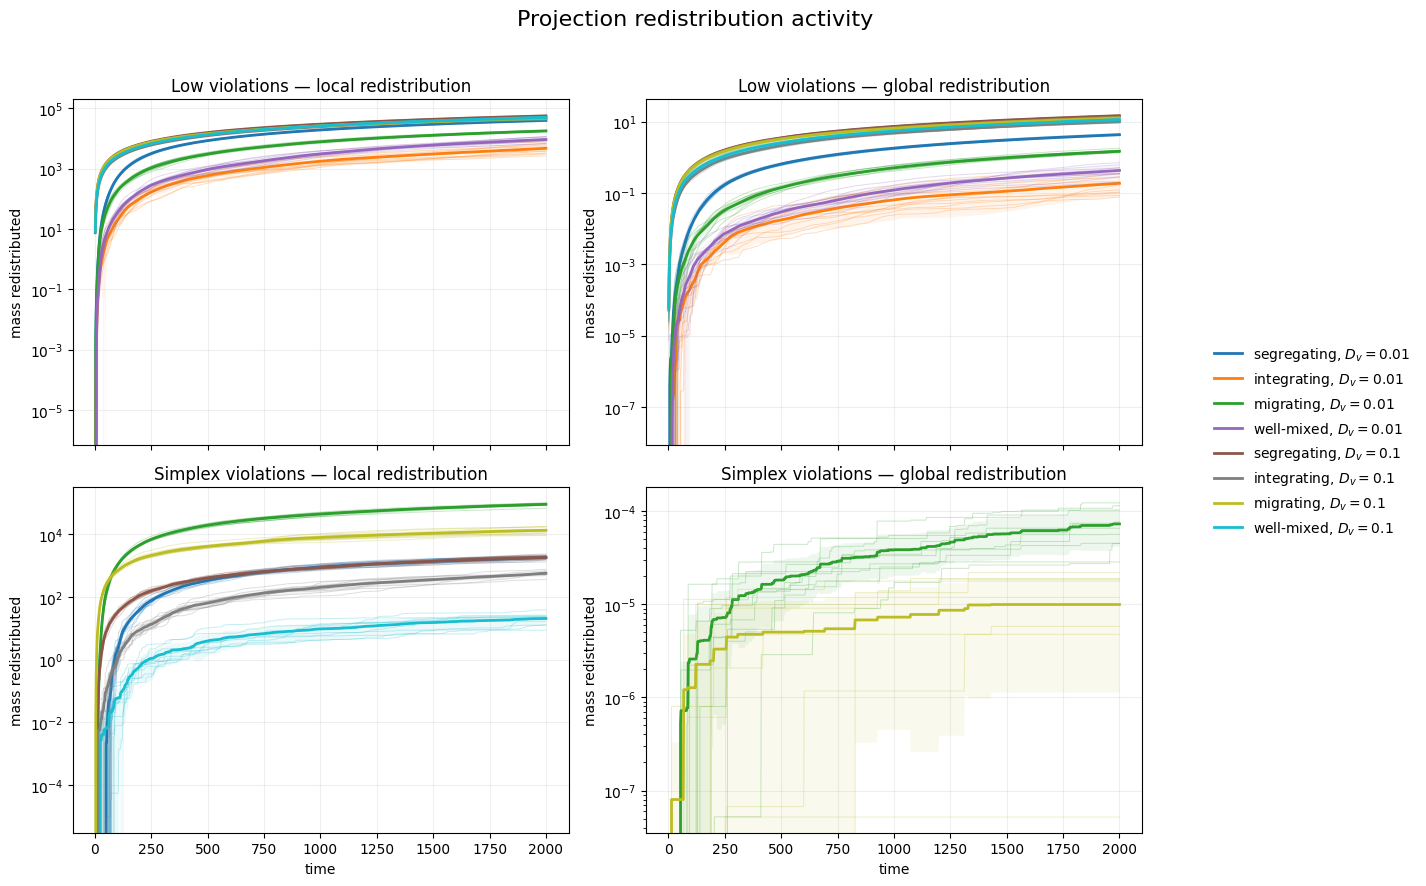

In [36]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

DV_VALUES = (0.01, 0.10)

# None -> use all runs found.
# Example: EXPECTED_NRUNS = 2 for your current local test.
EXPECTED_NRUNS = 10

# Usually several projection-history entries can correspond to the same
# physical time. Since these are amounts redistributed by individual calls,
# sum them at equal time.
AGGREGATE_SAME_TIME = "sum"

# Optional history-stage restriction.
# Leave None to include all projection calls.
STAGE_FILTER = "schelling"
# e.g. STAGE_FILTER = "schelling"

# "linear", "log", or "symlog"
YSCALE = "log"
SYMLOG_LINTHRESH = 1e-12


# =============================================================================
# Keys
# =============================================================================

DIAGNOSTICS = {
    "low_local":
        "proj_hist_mass_redistributed_low_local",

    "low_global":
        "proj_hist_mass_redistributed_low_global",

    "simplex_local":
        "proj_hist_mass_redistributed_simplex_local",

    "simplex_global":
        "proj_hist_mass_redistributed_simplex_global",
}


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def get_run_index(path):
    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):
    """
    Find all NPZ files for one regime and D_v.
    """
    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    paths = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):
        with np.load(
            path,
            allow_pickle=False,
        ) as z:
            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            paths.append(path)

    if EXPECTED_NRUNS is not None:
        if len(paths) != EXPECTED_NRUNS:
            raise RuntimeError(
                f"{regime}, D_v={target_Dv}: "
                f"expected {EXPECTED_NRUNS} runs, "
                f"found {len(paths)}"
            )

    return paths


# =============================================================================
# History processing
# =============================================================================

def aggregate_equal_times(time, values, mode="sum"):
    """
    Collapse multiple history entries that have exactly the same time.

    For redistribution activity, sum is the natural choice if each history
    row records the mass moved by an individual projection call.
    """
    time = np.asarray(time, dtype=float)
    values = np.asarray(values, dtype=float)

    order = np.argsort(time)

    time = time[order]
    values = values[order]

    unique_time, inverse = np.unique(
        time,
        return_inverse=True,
    )

    out = np.zeros(
        len(unique_time),
        dtype=float,
    )

    if mode == "sum":

        np.add.at(
            out,
            inverse,
            values,
        )

    elif mode == "mean":

        counts = np.zeros(
            len(unique_time),
            dtype=int,
        )

        np.add.at(
            out,
            inverse,
            values,
        )

        np.add.at(
            counts,
            inverse,
            1,
        )

        out /= counts

    elif mode == "last":

        # Useful only if your history entries were cumulative snapshots.
        for i, value in zip(
            inverse,
            values,
        ):
            out[i] = value

    else:
        raise ValueError(
            f"Unknown aggregation mode: {mode}"
        )

    return unique_time, out


def load_projection_history(path):
    """
    Load the four redistribution histories from one NPZ.
    """

    with np.load(
        path,
        allow_pickle=False,
    ) as z:

        # -------------------------------------------------------------
        # Time
        # -------------------------------------------------------------

        if "proj_hist_time" in z.files:

            time = z[
                "proj_hist_time"
            ].astype(float)

        elif (
            "proj_hist_step" in z.files
            and "dt" in z.files
        ):

            time = (
                z["proj_hist_step"].astype(float)
                * float(z["dt"])
            )

        else:

            raise KeyError(
                f"{path.name}: no projection-history time array"
            )

        # -------------------------------------------------------------
        # Optional stage filtering
        # -------------------------------------------------------------

        mask = np.ones(
            len(time),
            dtype=bool,
        )

        if STAGE_FILTER is not None:

            if "proj_hist_stage" not in z.files:
                raise KeyError(
                    f"{path.name}: "
                    "STAGE_FILTER requested but "
                    "proj_hist_stage is absent"
                )

            stages = z[
                "proj_hist_stage"
            ].astype(str)

            mask &= (
                stages == STAGE_FILTER
            )

        time = time[mask]

        # -------------------------------------------------------------
        # Four redistribution quantities
        # -------------------------------------------------------------

        histories = {}

        for name, key in DIAGNOSTICS.items():

            if key not in z.files:

                available = [
                    k for k in z.files
                    if k.startswith("proj_hist_")
                ]

                raise KeyError(
                    f"{path.name}: missing {key}\n"
                    f"Available projection-history keys:\n"
                    + "\n".join(available)
                )

            values = (
                z[key]
                .astype(float)[mask]
            )

            t_agg, values_agg = (
                aggregate_equal_times(
                    time,
                    values,
                    mode=AGGREGATE_SAME_TIME,
                )
            )

            histories[name] = (
                t_agg,
                values_agg,
            )

        return histories


# =============================================================================
# Ensemble helper
# =============================================================================

def interpolate_run_histories(run_histories):
    """
    Put multiple runs onto one common time grid.

    If all grids are identical, nothing changes.
    Otherwise interpolate over the common overlapping interval.
    """

    if len(run_histories) == 1:

        t, y = run_histories[0]

        return (
            t,
            np.asarray([y]),
        )

    # -------------------------------------------------------------
    # Fast path: identical grids
    # -------------------------------------------------------------

    t0 = run_histories[0][0]

    same_grid = all(
        len(t) == len(t0)
        and np.allclose(t, t0)
        for t, _ in run_histories
    )

    if same_grid:

        values = np.stack([
            y
            for _, y in run_histories
        ])

        return t0, values

    # -------------------------------------------------------------
    # Otherwise use common overlap and first run's sampling grid.
    # -------------------------------------------------------------

    t_min = max(
        t[0]
        for t, _ in run_histories
    )

    t_max = min(
        t[-1]
        for t, _ in run_histories
    )

    common_t = t0[
        (t0 >= t_min)
        & (t0 <= t_max)
    ]

    values = []

    for t, y in run_histories:

        values.append(
            np.interp(
                common_t,
                t,
                y,
            )
        )

    return (
        common_t,
        np.asarray(values),
    )


# =============================================================================
# Load all 8 parameter settings
# =============================================================================

settings = []

for Dv in DV_VALUES:

    for regime in REGIMES:

        paths = find_runs(
            regime,
            Dv,
        )

        runs = []

        for path in paths:

            runs.append({
                "run": get_run_index(path),
                "path": path,
                "history": load_projection_history(
                    path
                ),
            })

        settings.append({
            "regime": regime,
            "Dv": Dv,
            "runs": runs,
        })


# =============================================================================
# Figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
    sharex=True,
)

panel_info = [
    (
        axes[0, 0],
        "low_local",
        "Low violations — local redistribution",
    ),
    (
        axes[0, 1],
        "low_global",
        "Low violations — global redistribution",
    ),
    (
        axes[1, 0],
        "simplex_local",
        "Simplex violations — local redistribution",
    ),
    (
        axes[1, 1],
        "simplex_global",
        "Simplex violations — global redistribution",
    ),
]


# One color per parameter setting.
colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(settings),
    )
)


for setting_idx, setting in enumerate(
    settings
):

    color = colors[setting_idx]

    label = (
        f"{setting['regime']}, "
        fr"$D_v={setting['Dv']:g}$"
    )

    for ax, diagnostic, title in panel_info:

        run_series = [
            run["history"][diagnostic]
            for run in setting["runs"]
        ]

        if len(run_series) == 0:
            continue

        # ---------------------------------------------------------
        # Individual runs: thin and transparent
        # ---------------------------------------------------------

        for t, y in run_series:

            ax.plot(
                t,
                y,
                color=color,
                linewidth=0.7,
                alpha=0.25,
            )

        # ---------------------------------------------------------
        # Ensemble mean
        # ---------------------------------------------------------

        t_mean, values = (
            interpolate_run_histories(
                run_series
            )
        )

        mean = np.mean(
            values,
            axis=0,
        )

        ax.plot(
            t_mean,
            mean,
            color=color,
            linewidth=2.0,
            label=label,
        )

        # ---------------------------------------------------------
        # Run-to-run spread
        # ---------------------------------------------------------

        if values.shape[0] > 1:

            std = np.std(
                values,
                axis=0,
                ddof=1,
            )

            lower = np.maximum(
                mean - std,
                0.0,
            )

            upper = (
                mean + std
            )

            ax.fill_between(
                t_mean,
                lower,
                upper,
                color=color,
                alpha=0.08,
                linewidth=0,
            )


# =============================================================================
# Formatting
# =============================================================================

for ax, diagnostic, title in panel_info:

    ax.set_title(title)

    ax.set_ylabel(
        "mass redistributed"
    )

    ax.grid(
        alpha=0.2,
    )

    if YSCALE == "symlog":

        ax.set_yscale(
            "symlog",
            linthresh=SYMLOG_LINTHRESH,
        )

    else:

        ax.set_yscale(
            YSCALE
        )


axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")


# Global legend
handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

fig.suptitle(
    "Projection redistribution activity",
    fontsize=16,
)

plt.tight_layout(
    rect=[0, 0, 0.83, 0.96]
)

plt.show()

# Plot late-time coarsening in the different regimes

segregating  | D_v=0.01 | alpha=0.18966
segregating  | D_v=0.05 | alpha=0.30979
segregating  | D_v=0.08 | alpha=0.33760
segregating  | D_v=0.11 | alpha=0.14728
integrating  | D_v=0.01 | alpha=0.10921
integrating  | D_v=0.05 | alpha=0.11631
integrating  | D_v=0.08 | alpha=-0.09095
integrating  | D_v=0.11 | alpha=0.35531
migrating    | D_v=0.01 | alpha=0.23192
migrating    | D_v=0.05 | alpha=0.32482
migrating    | D_v=0.08 | alpha=0.28373
migrating    | D_v=0.11 | alpha=0.12851
well-mixed   | D_v=0.01 | alpha=0.11294
well-mixed   | D_v=0.05 | alpha=0.10862
well-mixed   | D_v=0.08 | alpha=0.03385
well-mixed   | D_v=0.11 | alpha=0.47215


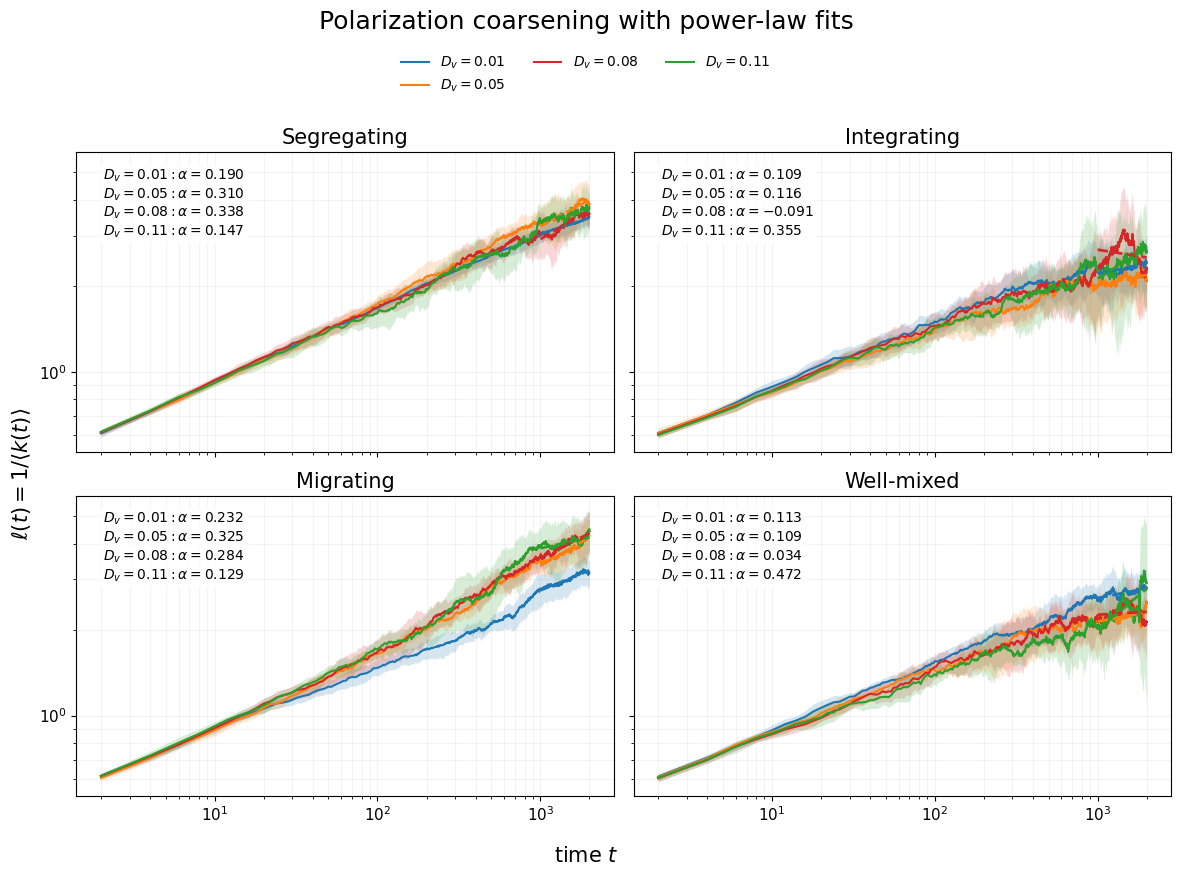

In [13]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_TITLES = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}


# =============================================================================
# Select the D_v values you want
# =============================================================================

DV_VALUES = (
    0.01,
    0.05,
    0.08,
    0.11
)

COLORS = {
    0.01: "tab:blue",
    0.05: "tab:orange",
    0.08: "tab:red",
    0.11: "tab:green",
}

EXPECTED_NRUNS = 10


# =============================================================================
# Plot styling
# =============================================================================

MEAN_LINEWIDTH = 1.5
FIT_LINEWIDTH = 2.0
UNCERTAINTY_ALPHA = 0.18

TITLE_FS = 15
LABEL_FS = 15
TICK_FS = 11
LEGEND_FS = 10
TEXT_FS = 10


# =============================================================================
# Definition of characteristic length
# =============================================================================

# False: ell = 1 / <k>
# True : ell = 2*pi / <k>
USE_2PI = False


# =============================================================================
# Fit controls
# =============================================================================

# Option 1:
# Fit the last FIT_TAIL_FRACTION of valid time points.
FIT_TAIL_FRACTION = 0.5

# Option 2:
# If not None, use only times t >= FIT_TMIN for the fit.
FIT_TMIN = None

# If not None, also impose an upper cutoff t <= FIT_TMAX
FIT_TMAX = None

# Minimum number of points required for a fit
MIN_FIT_POINTS = 8

# If True, show the fit exponent in the legend entry.
SHOW_EXPONENT_IN_LEGEND = False

# If False, use a text box in each panel instead.
SHOW_EXPONENT_TEXTBOX = True


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def run_index_from_path(path):

    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    paths = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            paths.append(path)

    paths = sorted(
        paths,
        key=run_index_from_path,
    )

    if (
        EXPECTED_NRUNS is not None
        and len(paths) != EXPECTED_NRUNS
    ):
        raise RuntimeError(
            f"{regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS} runs, "
            f"found {len(paths)}"
        )

    return paths


# =============================================================================
# Load characteristic length for an ensemble
# =============================================================================

def load_length_ensemble(regime, target_Dv):
    """
    Returns
    -------
    time : ndarray
        Common time grid.

    ell_runs : ndarray, shape (nruns, ntime)
        ell = 1 / <k_mean_pol> for every independent run.
    """

    paths = find_runs(
        regime,
        target_Dv,
    )

    time_ref = None
    ell_runs = []

    for path in paths:

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            time = z["time"].astype(float)
            k_mean = z["k_mean_pol"].astype(float)

        if time_ref is None:
            time_ref = time
        else:
            if (
                len(time) != len(time_ref)
                or not np.allclose(time, time_ref)
            ):
                raise RuntimeError(
                    f"Time grid mismatch in {path}"
                )

        ell = np.full_like(
            k_mean,
            np.nan,
            dtype=float,
        )

        valid = (
            np.isfinite(k_mean)
            & (k_mean > 0)
        )

        if USE_2PI:
            ell[valid] = 2.0 * np.pi / k_mean[valid]
        else:
            ell[valid] = 1.0 / k_mean[valid]

        ell_runs.append(ell)

    ell_runs = np.stack(
        ell_runs,
        axis=0,
    )

    return time_ref, ell_runs


# =============================================================================
# Power-law fit helper
# =============================================================================

def fit_power_law(time, y):
    """
    Fit y ~ A * t^alpha in log-log space.

    Returns
    -------
    alpha : float
    A : float
    fit_mask : ndarray[bool]
    """

    time = np.asarray(time, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(time)
        & (time > 0)
        & np.isfinite(y)
        & (y > 0)
    )

    time = time[valid]
    y = y[valid]

    if len(time) < MIN_FIT_POINTS:
        return np.nan, np.nan, valid

    # -------------------------------------------------------------
    # Build fit mask
    # -------------------------------------------------------------
    fit_mask_local = np.ones(
        len(time),
        dtype=bool,
    )

    if FIT_TMIN is not None:
        fit_mask_local &= (time >= FIT_TMIN)

    if FIT_TMAX is not None:
        fit_mask_local &= (time <= FIT_TMAX)

    # If no explicit lower cutoff, use the tail fraction
    if FIT_TMIN is None:
        start_idx = int(
            np.floor((1.0 - FIT_TAIL_FRACTION) * len(time))
        )
        start_idx = max(0, min(start_idx, len(time) - 1))
        fit_mask_local &= (
            np.arange(len(time)) >= start_idx
        )

    if np.sum(fit_mask_local) < MIN_FIT_POINTS:
        return np.nan, np.nan, valid

    t_fit = time[fit_mask_local]
    y_fit = y[fit_mask_local]

    coeffs = np.polyfit(
        np.log(t_fit),
        np.log(y_fit),
        1,
    )

    alpha = coeffs[0]
    logA = coeffs[1]
    A = np.exp(logA)

    # map back to mask in original array size
    fit_mask_global = np.zeros_like(valid, dtype=bool)
    fit_mask_global[np.where(valid)[0][fit_mask_local]] = True

    return alpha, A, fit_mask_global


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for ax, regime in zip(axes, REGIMES):

    textbox_lines = []

    for Dv in DV_VALUES:

        time, ell_runs = load_length_ensemble(
            regime,
            Dv,
        )

        color = COLORS[Dv]

        # -------------------------------------------------------------
        # Ensemble statistics
        # -------------------------------------------------------------
        ell_mean = np.nanmean(
            ell_runs,
            axis=0,
        )

        ell_std = np.nanstd(
            ell_runs,
            axis=0,
            ddof=1,
        )

        valid = (
            np.isfinite(time)
            & (time > 0)
            & np.isfinite(ell_mean)
            & (ell_mean > 0)
        )

        t_plot = time[valid]
        mean_plot = ell_mean[valid]
        std_plot = ell_std[valid]

        # -------------------------------------------------------------
        # Main mean curve
        # -------------------------------------------------------------
        if SHOW_EXPONENT_IN_LEGEND:
            label = fr"$D_v={Dv:.2f}$"
        else:
            label = fr"$D_v={Dv:.2f}$"

        ax.plot(
            t_plot,
            mean_plot,
            color=color,
            linewidth=MEAN_LINEWIDTH,
            label=label,
            zorder=3,
        )

        # -------------------------------------------------------------
        # Uncertainty band
        # -------------------------------------------------------------
        lower = np.maximum(
            mean_plot - std_plot,
            np.finfo(float).tiny,
        )
        upper = mean_plot + std_plot

        ax.fill_between(
            t_plot,
            lower,
            upper,
            color=color,
            alpha=UNCERTAINTY_ALPHA,
            linewidth=0,
            zorder=2,
        )

        # -------------------------------------------------------------
        # Fit power-law to the mean curve
        # -------------------------------------------------------------
        alpha, A, fit_mask = fit_power_law(
            time,
            ell_mean,
        )

        if np.isfinite(alpha) and np.isfinite(A):

            t_fit = time[fit_mask]
            y_fit = A * t_fit**alpha

            ax.plot(
                t_fit,
                y_fit,
                linestyle="--",
                color=color,
                linewidth=FIT_LINEWIDTH,
                zorder=4,
            )

            if SHOW_EXPONENT_IN_LEGEND:
                # add a short invisible line just for legend text
                ax.plot(
                    [],
                    [],
                    linestyle="--",
                    color=color,
                    linewidth=FIT_LINEWIDTH,
                    label=fr"fit: $\alpha={alpha:.3f}$",
                )
            elif SHOW_EXPONENT_TEXTBOX:
                textbox_lines.append(
                    fr"$D_v={Dv:.2f}: \alpha={alpha:.3f}$"
                )

            print(
                f"{regime:12s} | D_v={Dv:.2f} | alpha={alpha:.5f}"
            )

    # -------------------------------------------------------------
    # Log-log scales
    # -------------------------------------------------------------
    ax.set_xscale("log")
    ax.set_yscale("log")

    # -------------------------------------------------------------
    # Panel styling
    # -------------------------------------------------------------
    ax.set_title(
        REGIME_TITLES[regime],
        fontsize=TITLE_FS,
    )

    ax.grid(
        alpha=0.15,
        which="both",
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
    )

    if SHOW_EXPONENT_TEXTBOX and len(textbox_lines) > 0:
        ax.text(
            0.05,
            0.95,
            "\n".join(textbox_lines),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=TEXT_FS,
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
            ),
        )


# =============================================================================
# Shared labels
# =============================================================================

fig.supxlabel(
    r"time $t$",
    fontsize=LABEL_FS,
)

if USE_2PI:
    ylabel = r"$\ell(t)=2\pi/\langle k(t)\rangle$"
else:
    ylabel = r"$\ell(t)=1/\langle k(t)\rangle$"

fig.supylabel(
    ylabel,
    fontsize=LABEL_FS,
)


# =============================================================================
# Shared legend
# =============================================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
    fontsize=LEGEND_FS,
    frameon=False,
)

fig.suptitle(
    "Polarization coarsening with power-law fits",
    fontsize=18,
    y=1.08,
)

fig.tight_layout()
plt.show()

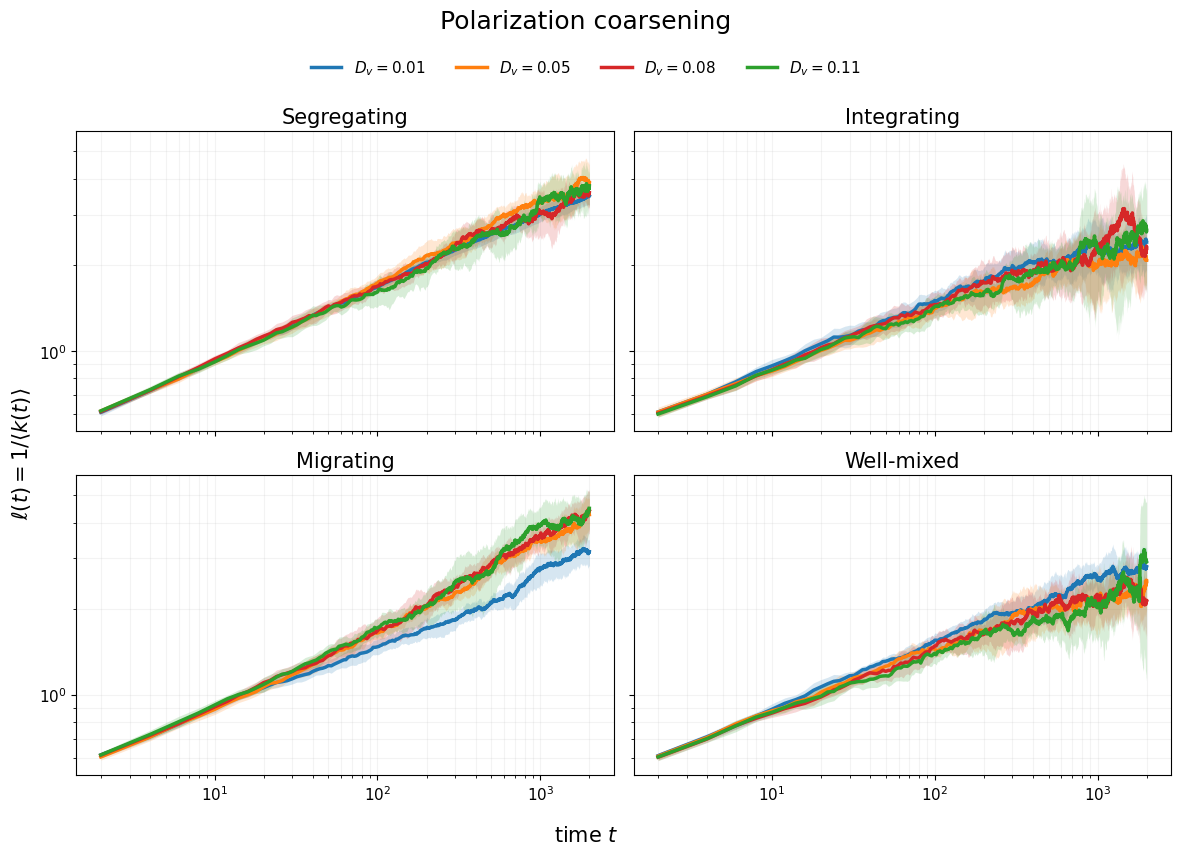

In [26]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_TITLES = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}


# =============================================================================
# Select the D_v values you want
# =============================================================================

DV_VALUES = (
    0.01,
    0.05,
    0.08,
    0.11,
)

# Matching colors
COLORS = {
    0.01: "tab:blue",
    0.05: "tab:orange",
    0.08: "tab:red",
    0.11: "tab:green",
}

EXPECTED_NRUNS = 10


# =============================================================================
# Plot styling
# =============================================================================

MEAN_LINEWIDTH = 2.5
UNCERTAINTY_ALPHA = 0.18

TITLE_FS = 15
LABEL_FS = 15
TICK_FS = 11
LEGEND_FS = 11


# =============================================================================
# Definition of characteristic length
# =============================================================================

# False:
#
#       ell = 1 / <k>
#
# True:
#
#       ell = 2*pi / <k>
#
# You asked for 1/<k>, so False is the default.
USE_2PI = False


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def run_index_from_path(path):

    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():

        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    paths = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(
                z["D_v"]
            )

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):

            paths.append(path)


    paths = sorted(
        paths,
        key=run_index_from_path,
    )


    if (
        EXPECTED_NRUNS is not None
        and len(paths) != EXPECTED_NRUNS
    ):

        raise RuntimeError(
            f"{regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS} runs, "
            f"found {len(paths)}"
        )

    return paths


# =============================================================================
# Load characteristic length for an ensemble
# =============================================================================

def load_length_ensemble(regime, target_Dv):
    """
    Returns
    -------
    time : ndarray
        Common time grid.

    ell_runs : ndarray, shape (nruns, ntime)
        ell = 1 / <k> for every independent run.
    """

    paths = find_runs(
        regime,
        target_Dv,
    )

    time_ref = None
    ell_runs = []


    for path in paths:

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            time = (
                z["time"]
                .astype(float)
            )

            k_mean = (
                z["k_mean_pol"]
                .astype(float)
            )


        if time_ref is None:

            time_ref = time

        else:

            if (
                len(time) != len(time_ref)
                or not np.allclose(
                    time,
                    time_ref,
                )
            ):

                raise RuntimeError(
                    f"Time grid mismatch in {path}"
                )


        # -------------------------------------------------------------
        # Characteristic length
        # -------------------------------------------------------------

        ell = np.full_like(
            k_mean,
            np.nan,
            dtype=float,
        )

        valid = (
            np.isfinite(k_mean)
            & (k_mean > 0)
        )

        if USE_2PI:

            ell[valid] = (
                2.0 * np.pi
                / k_mean[valid]
            )

        else:

            ell[valid] = (
                1.0
                / k_mean[valid]
            )


        ell_runs.append(
            ell
        )


    ell_runs = np.stack(
        ell_runs,
        axis=0,
    )

    return (
        time_ref,
        ell_runs,
    )


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()


for ax, regime in zip(
    axes,
    REGIMES,
):

    for Dv in DV_VALUES:

        time, ell_runs = (
            load_length_ensemble(
                regime,
                Dv,
            )
        )

        color = COLORS[Dv]


        # =============================================================
        # Ensemble statistics
        # =============================================================

        ell_mean = np.nanmean(
            ell_runs,
            axis=0,
        )

        ell_std = np.nanstd(
            ell_runs,
            axis=0,
            ddof=1,
        )


        # =============================================================
        # Need t > 0 for logarithmic x-axis
        # =============================================================

        valid = (
            np.isfinite(time)
            & (time > 0)
            & np.isfinite(ell_mean)
            & (ell_mean > 0)
        )

        t_plot = time[valid]

        mean_plot = ell_mean[valid]

        std_plot = ell_std[valid]


        # =============================================================
        # Mean trajectory
        # =============================================================

        ax.plot(
            t_plot,
            mean_plot,
            color=color,
            linewidth=MEAN_LINEWIDTH,
            label=fr"$D_v={Dv:.2f}$",
            zorder=3,
        )


        # =============================================================
        # Run-to-run standard deviation
        #
        # On log y axes the lower edge must remain positive.
        # =============================================================

        lower = np.maximum(
            mean_plot - std_plot,
            np.finfo(float).tiny,
        )

        upper = (
            mean_plot + std_plot
        )

        ax.fill_between(
            t_plot,
            lower,
            upper,
            color=color,
            alpha=UNCERTAINTY_ALPHA,
            linewidth=0,
            zorder=2,
        )


    # =================================================================
    # Log-log scales
    # =================================================================

    ax.set_xscale("log")
    ax.set_yscale("log")


    # =================================================================
    # Panel styling
    # =================================================================

    ax.set_title(
        REGIME_TITLES[regime],
        fontsize=TITLE_FS,
    )

    ax.grid(
        alpha=0.15,
        which="both",
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
    )


# =============================================================================
# Shared labels
# =============================================================================

fig.supxlabel(
    r"time $t$",
    fontsize=LABEL_FS,
)

if USE_2PI:

    ylabel = (
        r"$\ell(t)=2\pi/\langle k(t)\rangle$"
    )

else:

    ylabel = (
        r"$\ell(t)=1/\langle k(t)\rangle$"
    )


fig.supylabel(
    ylabel,
    fontsize=LABEL_FS,
)


# =============================================================================
# Shared legend
# =============================================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(DV_VALUES),
    fontsize=LEGEND_FS,
    frameon=False,
)


fig.suptitle(
    "Polarization coarsening",
    fontsize=18,
    y=1.055,
)


fig.tight_layout()

plt.show()

# Density of interfaces

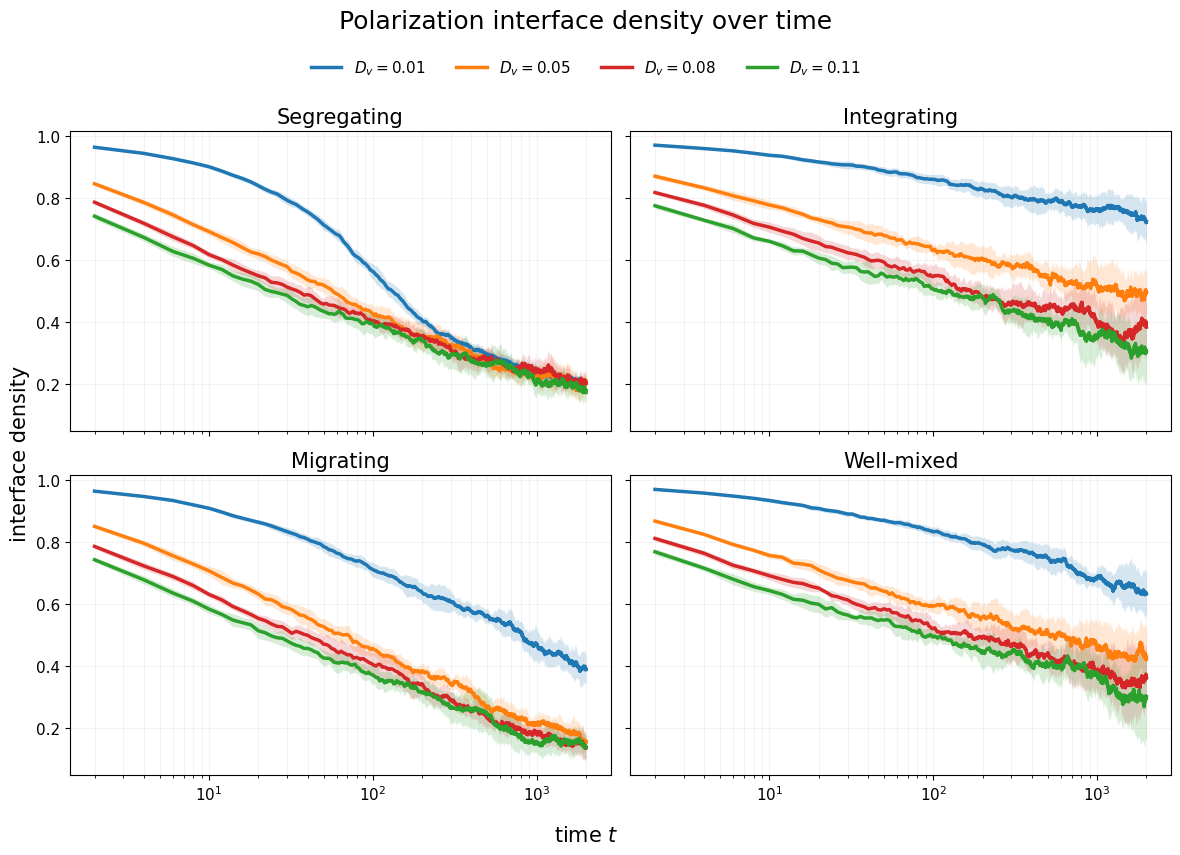

In [15]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

REGIME_TITLES = {
    "segregating": "Segregating",
    "integrating": "Integrating",
    "migrating": "Migrating",
    "well-mixed": "Well-mixed",
}


# =============================================================================
# Select D_v values and colors
# =============================================================================

DV_VALUES = (
    0.01,
    0.05,
    0.08,
    0.11,
)

# Matching colors
COLORS = {
    0.01: "tab:blue",
    0.05: "tab:orange",
    0.08: "tab:red",
    0.11: "tab:green",
}


EXPECTED_NRUNS = 10


# =============================================================================
# Plot styling
# =============================================================================

MEAN_LINEWIDTH = 2.5
UNCERTAINTY_ALPHA = 0.18

TITLE_FS = 15
LABEL_FS = 15
TICK_FS = 11
LEGEND_FS = 11

# Useful for coarsening dynamics
LOG_X = True

# Interface density itself is usually better left on a linear y-axis.
LOG_Y = False


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def run_index_from_path(path):

    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    paths = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(
                z["D_v"]
            )

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            paths.append(path)

    paths = sorted(
        paths,
        key=run_index_from_path,
    )

    if (
        EXPECTED_NRUNS is not None
        and len(paths) != EXPECTED_NRUNS
    ):
        raise RuntimeError(
            f"{regime}, D_v={target_Dv:.2f}: "
            f"expected {EXPECTED_NRUNS} runs, "
            f"found {len(paths)}"
        )

    return paths


# =============================================================================
# Load interface-density ensemble
# =============================================================================

def load_interface_ensemble(
    regime,
    target_Dv,
):
    """
    Returns
    -------
    time : ndarray, shape (ntime,)

    interface_runs : ndarray, shape (nruns, ntime)
        Interface density for every independent run.
    """

    paths = find_runs(
        regime,
        target_Dv,
    )

    time_ref = None
    interface_runs = []

    for path in paths:

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            time = (
                z["time"]
                .astype(float)
            )

            interface = (
                z["interface_density"]
                .astype(float)
            )

        if time_ref is None:

            time_ref = time

        else:

            if (
                len(time) != len(time_ref)
                or not np.allclose(
                    time,
                    time_ref,
                )
            ):

                raise RuntimeError(
                    f"Time-grid mismatch in {path}"
                )

        if len(interface) != len(time):

            raise RuntimeError(
                f"Observable/time mismatch in {path}"
            )

        interface_runs.append(
            interface
        )

    interface_runs = np.stack(
        interface_runs,
        axis=0,
    )

    return (
        time_ref,
        interface_runs,
    )


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()


for ax, regime in zip(
    axes,
    REGIMES,
):

    for Dv in DV_VALUES:

        time, runs = (
            load_interface_ensemble(
                regime,
                Dv,
            )
        )

        color = COLORS[Dv]


        # =============================================================
        # Ensemble statistics
        # =============================================================

        mean = np.nanmean(
            runs,
            axis=0,
        )

        std = np.nanstd(
            runs,
            axis=0,
            ddof=1,
        )


        # =============================================================
        # Exclude t=0 when using a log x-axis
        # =============================================================

        valid = (
            np.isfinite(time)
            & np.isfinite(mean)
        )

        if LOG_X:
            valid &= (time > 0)

        if LOG_Y:
            valid &= (mean > 0)

        t_plot = time[valid]
        mean_plot = mean[valid]
        std_plot = std[valid]


        # =============================================================
        # Ensemble mean
        # =============================================================

        ax.plot(
            t_plot,
            mean_plot,
            color=color,
            linewidth=MEAN_LINEWIDTH,
            label=fr"$D_v={Dv:.2f}$",
            zorder=3,
        )


        # =============================================================
        # Run-to-run standard deviation
        # =============================================================

        lower = (
            mean_plot
            - std_plot
        )

        if LOG_Y:

            lower = np.maximum(
                lower,
                np.finfo(float).tiny,
            )

        else:

            # Interface density should not be negative
            lower = np.maximum(
                lower,
                0.0,
            )

        upper = (
            mean_plot
            + std_plot
        )

        ax.fill_between(
            t_plot,
            lower,
            upper,
            color=color,
            alpha=UNCERTAINTY_ALPHA,
            linewidth=0,
            zorder=2,
        )


    # =================================================================
    # Axes
    # =================================================================

    if LOG_X:
        ax.set_xscale("log")

    if LOG_Y:
        ax.set_yscale("log")


    # =================================================================
    # Panel styling
    # =================================================================

    ax.set_title(
        REGIME_TITLES[regime],
        fontsize=TITLE_FS,
    )

    ax.grid(
        alpha=0.15,
        which="both",
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
    )


# =============================================================================
# Shared labels
# =============================================================================

fig.supxlabel(
    r"time $t$",
    fontsize=LABEL_FS,
)

fig.supylabel(
    r"interface density",
    fontsize=LABEL_FS,
)


# =============================================================================
# Shared legend
# =============================================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(DV_VALUES),
    fontsize=LEGEND_FS,
    frameon=False,
)


fig.suptitle(
    "Polarization interface density over time",
    fontsize=18,
    y=1.055,
)

fig.tight_layout()

plt.show()

# $S_{pol}$ and $S_{occ}$ for selected $k$ values

Loaded 10 run(s) for well-mixed, D_v=0.2

Selected k bins:
low : bin= 1, k=0.21721
mid : bin=25, k=3.69252
high: bin=48, k=7.02302

Theory normalizations:
run  0: amp=1.85957
run  1: amp=1.79604
run  2: amp=1.95508
run  3: amp=1.59133
run  4: amp=1.91098
run  5: amp=1.75801
run  6: amp=1.76162
run  7: amp=1.53645
run  8: amp=1.02291
run  9: amp=1.10855


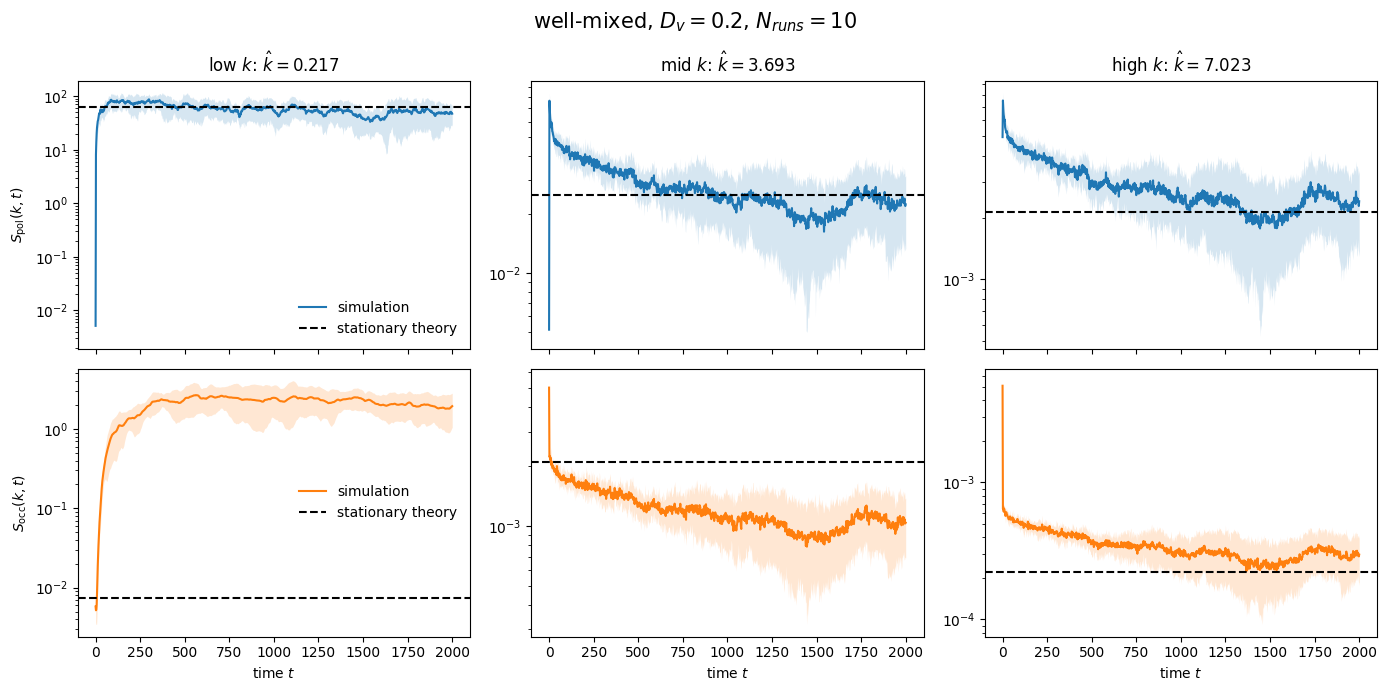

In [32]:

# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

# Choose one setting to inspect.
REGIME = "well-mixed"
DV = 0.2

# None = use all available runs for this setting.
# Set to an integer, e.g. 0, to inspect one particular run.
RUN_INDEX = None

# Automatically choose low / middle / high radial bins.
# If you want explicit indices, use e.g.:
# K_BIN_INDICES = (2, 20, 40)
K_BIN_INDICES = None

THEORY_SKIP = 1


# =============================================================================
# File helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def get_run_index(path):

    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():

        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    matches = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):

        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            atol=1e-12,
            rtol=0.0,
        ):

            if (
                RUN_INDEX is None
                or get_run_index(path) == RUN_INDEX
            ):
                matches.append(path)

    if not matches:

        raise FileNotFoundError(
            f"No runs found for "
            f"{regime}, D_v={target_Dv}"
        )

    return matches


# =============================================================================
# Theory normalization helpers
# =============================================================================

def fit_amplitude_logspace(
    theory,
    data,
):

    theory = np.asarray(theory)
    data = np.asarray(data)

    valid = (
        np.isfinite(theory)
        & np.isfinite(data)
        & (theory > 0)
        & (data > 0)
    )

    if not np.any(valid):
        return 1.0

    return np.exp(
        np.mean(
            np.log(data[valid])
            - np.log(theory[valid])
        )
    )


def get_dynamic_fit_mask(
    k,
    S_AA,
    S_BB,
    S_AB,
    n_after_peak=2,
):

    k_mask = (
        np.isfinite(k)
        & (k > 0)
    )

    envelope = np.nanmax(
        np.vstack([
            np.where(
                k_mask,
                S_AA,
                np.nan,
            ),
            np.where(
                k_mask,
                S_BB,
                np.nan,
            ),
            np.where(
                k_mask,
                np.abs(S_AB),
                np.nan,
            ),
        ]),
        axis=0,
    )

    if np.all(np.isnan(envelope)):

        start = 1

    else:

        start = (
            np.nanargmax(envelope)
            + n_after_peak
        )

    indices = np.arange(len(k))

    mask = (
        k_mask
        & (indices >= start)
    )

    if np.sum(mask) < 3:

        mask = (
            k_mask
            & (
                indices
                >= max(1, start - n_after_peak)
            )
        )

    return mask


# =============================================================================
# Load one run
# =============================================================================

def load_one_run(path):

    with np.load(
        path,
        allow_pickle=False,
    ) as z:

        out = {
            "path": path,
            "run_index": get_run_index(path),

            "time": z["time"].copy(),
            "k": z["k_centers"].copy(),

            "S_pol": z["S_pol"].copy(),
            "S_occ": z["S_occ"].copy(),

            "S_AA_tail": z[
                "S_AA_tail_mean"
            ].copy(),

            "S_BB_tail": z[
                "S_BB_tail_mean"
            ].copy(),

            "S_AB_tail": z[
                "S_AB_tail_mean"
            ].copy(),

            "rhoA": float(
                np.mean(
                    z["mean_A"][
                        z["tail_frame_indices"]
                    ]
                )
            ),

            "rhoB": float(
                np.mean(
                    z["mean_B"][
                        z["tail_frame_indices"]
                    ]
                )
            ),

            "params": {
                "h": float(z["h"]),
                "D": z["D"].copy(),
                "Gamma": z["Gamma"].copy(),
                "beta": float(z["beta"]),
                "kappa": z["kappa"].copy(),
                "D_v": float(z["D_v"]),
            },
        }

    return out


# =============================================================================
# Theory for one run
# =============================================================================

def theory_for_run(run):

    k = run["k"]

    nk = len(k)

    S_AA = np.zeros(nk)
    S_AB = np.zeros(nk)
    S_BB = np.zeros(nk)

    for i, kval in enumerate(k):

        S = structure_factor(
            kval,
            run["rhoA"],
            run["rhoB"],
            run["params"],
        )

        S_AA[i] = np.real(S[0, 0])
        S_AB[i] = np.real(S[0, 1])
        S_BB[i] = np.real(S[1, 1])

    # -------------------------------------------------------------
    # Use exactly the same common amplitude normalization as
    # the static spectrum comparison.
    # -------------------------------------------------------------

    fit_mask = get_dynamic_fit_mask(
        k,
        run["S_AA_tail"],
        run["S_BB_tail"],
        run["S_AB_tail"],
        n_after_peak=2,
    )

    theory_fit = np.vstack([
        S_AA[fit_mask],
        S_BB[fit_mask],
        np.abs(S_AB[fit_mask]),
    ])

    data_fit = np.vstack([
        run["S_AA_tail"][fit_mask],
        run["S_BB_tail"][fit_mask],
        np.abs(
            run["S_AB_tail"][fit_mask]
        ),
    ])

    amp = fit_amplitude_logspace(
        theory_fit,
        data_fit,
    )

    # -------------------------------------------------------------
    # Derived modes
    # -------------------------------------------------------------

    S_pol = (
        S_AA
        + S_BB
        - 2.0 * S_AB
    )

    S_occ = (
        S_AA
        + S_BB
        + 2.0 * S_AB
    )

    return {
        "amp": amp,
        "S_pol": amp * S_pol,
        "S_occ": amp * S_occ,
    }


# =============================================================================
# Load all requested runs
# =============================================================================

paths = find_runs(
    REGIME,
    DV,
)

runs = [
    load_one_run(path)
    for path in paths
]

print(
    f"Loaded {len(runs)} run(s) for "
    f"{REGIME}, D_v={DV}"
)


# =============================================================================
# Verify grids are identical
# =============================================================================

time = runs[0]["time"]
k = runs[0]["k"]

for run in runs[1:]:

    if not np.array_equal(
        run["time"],
        time,
    ):

        raise RuntimeError(
            "Runs do not have the same time grid. "
            "Do not mix 10k and 100k-step runs "
            "in the same analysis directory."
        )

    if not np.allclose(
        run["k"],
        k,
    ):

        raise RuntimeError(
            "Runs do not have the same k grid."
        )


# =============================================================================
# Choose low / mid / high k bins
# =============================================================================

if K_BIN_INDICES is None:

    positive = np.where(
        np.isfinite(k)
        & (k > 0)
    )[0]

    # Avoid the very first and very last radial bin because
    # those can be slightly unusual owing to bin geometry.
    low_idx = positive[
        min(1, len(positive) - 1)
    ]

    mid_idx = positive[
        len(positive) // 2
    ]

    high_idx = positive[
        max(0, len(positive) - 2)
    ]

    k_indices = (
        low_idx,
        mid_idx,
        high_idx,
    )

else:

    k_indices = tuple(
        K_BIN_INDICES
    )


print("\nSelected k bins:")
for name, idx in zip(
    ("low", "mid", "high"),
    k_indices,
):

    print(
        f"{name:4s}: "
        f"bin={idx:2d}, "
        f"k={k[idx]:.5f}"
    )


# =============================================================================
# Stack simulation data
# =============================================================================

S_pol_runs = np.stack([
    run["S_pol"]
    for run in runs
])

S_occ_runs = np.stack([
    run["S_occ"]
    for run in runs
])

# Shapes:
#     (nruns, ntime, nk)

S_pol_mean = np.mean(
    S_pol_runs,
    axis=0,
)

S_occ_mean = np.mean(
    S_occ_runs,
    axis=0,
)


if len(runs) > 1:

    S_pol_std = np.std(
        S_pol_runs,
        axis=0,
        ddof=1,
    )

    S_occ_std = np.std(
        S_occ_runs,
        axis=0,
        ddof=1,
    )

else:

    S_pol_std = None
    S_occ_std = None


# =============================================================================
# Theory for each run, then average
# =============================================================================

theories = [
    theory_for_run(run)
    for run in runs
]

S_pol_theory_runs = np.stack([
    th["S_pol"]
    for th in theories
])

S_occ_theory_runs = np.stack([
    th["S_occ"]
    for th in theories
])

S_pol_theory = np.mean(
    S_pol_theory_runs,
    axis=0,
)

S_occ_theory = np.mean(
    S_occ_theory_runs,
    axis=0,
)


print("\nTheory normalizations:")
for run, th in zip(
    runs,
    theories,
):

    print(
        f"run {run['run_index']:2d}: "
        f"amp={th['amp']:.6g}"
    )


# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 7),
    sharex=True,
)

labels = (
    "low",
    "mid",
    "high",
)


for col, (label, idx) in enumerate(
    zip(labels, k_indices)
):

    # =============================================================
    # Polarization
    # =============================================================

    ax = axes[0, col]

    y = S_pol_mean[:, idx]

    valid = (
        np.isfinite(y)
        & (y > 0)
    )

    ax.plot(
        time[valid],
        y[valid],
        color="tab:blue",
        linewidth=1.5,
        label="simulation",
    )

    if S_pol_std is not None:

        sd = S_pol_std[:, idx]

        lower = np.maximum(
            y - sd,
            np.finfo(float).tiny,
        )

        upper = y + sd

        ax.fill_between(
            time,
            lower,
            upper,
            color="tab:blue",
            alpha=0.18,
            linewidth=0,
        )

    theory_value = (
        S_pol_theory[idx]
    )

    if (
        np.isfinite(theory_value)
        and theory_value > 0
    ):

        ax.axhline(
            theory_value,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="stationary theory",
        )

    ax.set_yscale("log")

    ax.set_title(
        fr"{label} $k$: "
        fr"$\hat{{k}}={k[idx]:.3f}$"
    )

    if col == 0:

        ax.set_ylabel(
            r"$S_{\rm pol}(k,t)$"
        )

        ax.legend(
            frameon=False,
        )


    # =============================================================
    # Occupancy
    # =============================================================

    ax = axes[1, col]

    y = S_occ_mean[:, idx]

    valid = (
        np.isfinite(y)
        & (y > 0)
    )

    ax.plot(
        time[valid],
        y[valid],
        color="tab:orange",
        linewidth=1.5,
        label="simulation",
    )

    if S_occ_std is not None:

        sd = S_occ_std[:, idx]

        lower = np.maximum(
            y - sd,
            np.finfo(float).tiny,
        )

        upper = y + sd

        ax.fill_between(
            time,
            lower,
            upper,
            color="tab:orange",
            alpha=0.18,
            linewidth=0,
        )

    theory_value = (
        S_occ_theory[idx]
    )

    if (
        np.isfinite(theory_value)
        and theory_value > 0
    ):

        ax.axhline(
            theory_value,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="stationary theory",
        )

    ax.set_yscale("log")

    ax.set_xlabel(
        r"time $t$"
    )

    if col == 0:

        ax.set_ylabel(
            r"$S_{\rm occ}(k,t)$"
        )

        ax.legend(
            frameon=False,
        )


fig.suptitle(
    fr"{REGIME}, $D_v={DV:g}$, "
    fr"$N_{{runs}}={len(runs)}$",
    fontsize=15,
)

plt.tight_layout()
plt.show()

# Occupied spectrum diagnostics


Selected k bins
low : index= 5, k=0.796425
mid : index=27, k=3.982126
high: index=47, k=6.878217

Loading segregating
D_v=0.01: 10 runs
D_v=0.02: 10 runs
D_v=0.03: 10 runs
D_v=0.04: 10 runs
D_v=0.05: 10 runs
D_v=0.06: 10 runs
D_v=0.07: 10 runs
D_v=0.08: 10 runs
D_v=0.09: 10 runs
D_v=0.10: 10 runs
D_v=0.11: 10 runs
D_v=0.12: 10 runs
D_v=0.13: 10 runs
D_v=0.14: 10 runs
D_v=0.15: 10 runs
D_v=0.16: 10 runs
D_v=0.17: 10 runs
D_v=0.18: 10 runs
D_v=0.19: 10 runs
D_v=0.20: 10 runs

Loading integrating
D_v=0.01: 10 runs
D_v=0.02: 10 runs
D_v=0.03: 10 runs
D_v=0.04: 10 runs
D_v=0.05: 10 runs
D_v=0.06: 10 runs
D_v=0.07: 10 runs
D_v=0.08: 10 runs
D_v=0.09: 10 runs
D_v=0.10: 10 runs
D_v=0.11: 10 runs
D_v=0.12: 10 runs
D_v=0.13: 10 runs
D_v=0.14: 10 runs
D_v=0.15: 10 runs
D_v=0.16: 10 runs
D_v=0.17: 10 runs
D_v=0.18: 10 runs
D_v=0.19: 10 runs
D_v=0.20: 10 runs

Loading migrating
D_v=0.01: 10 runs
D_v=0.02: 10 runs
D_v=0.03: 10 runs
D_v=0.04: 10 runs
D_v=0.05: 10 runs
D_v=0.06: 10 runs
D_v=0.07: 10 

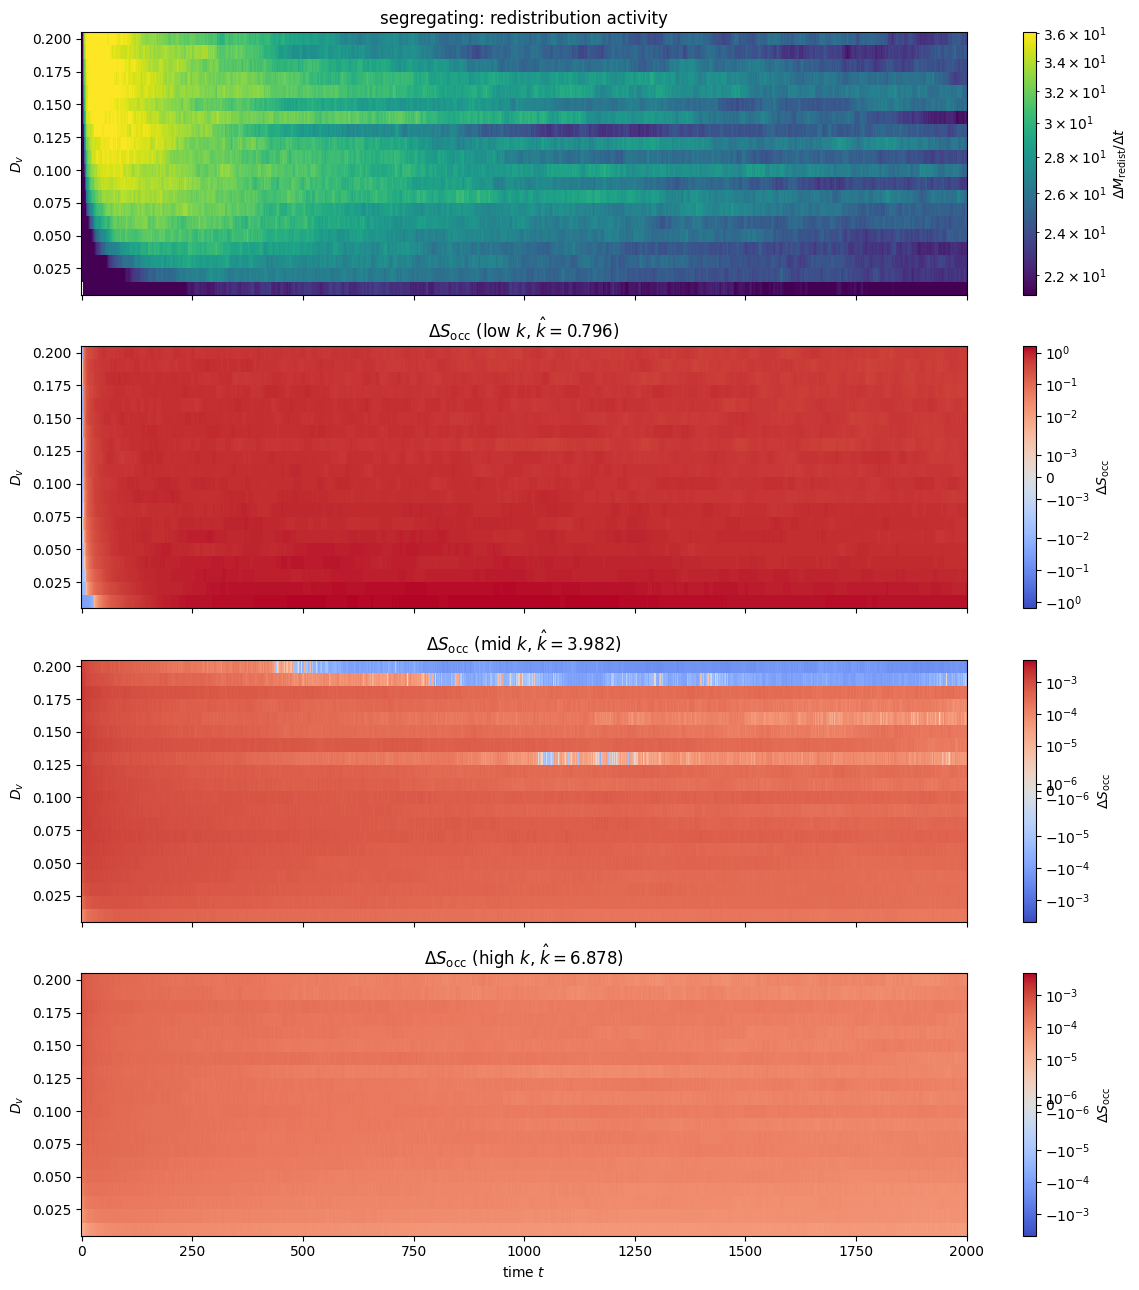

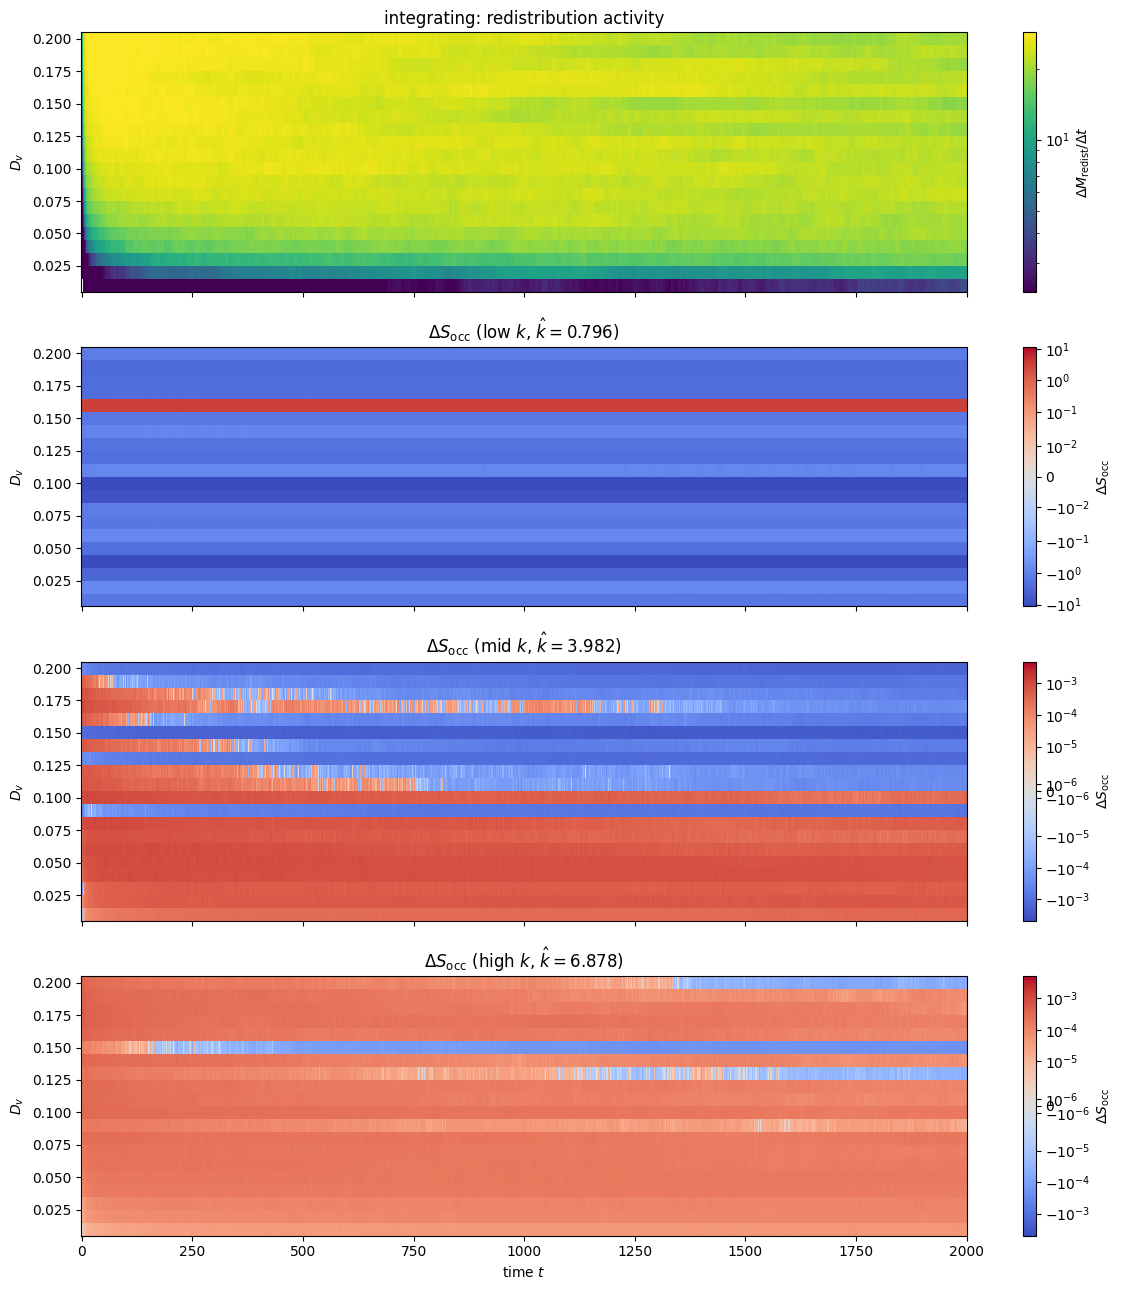

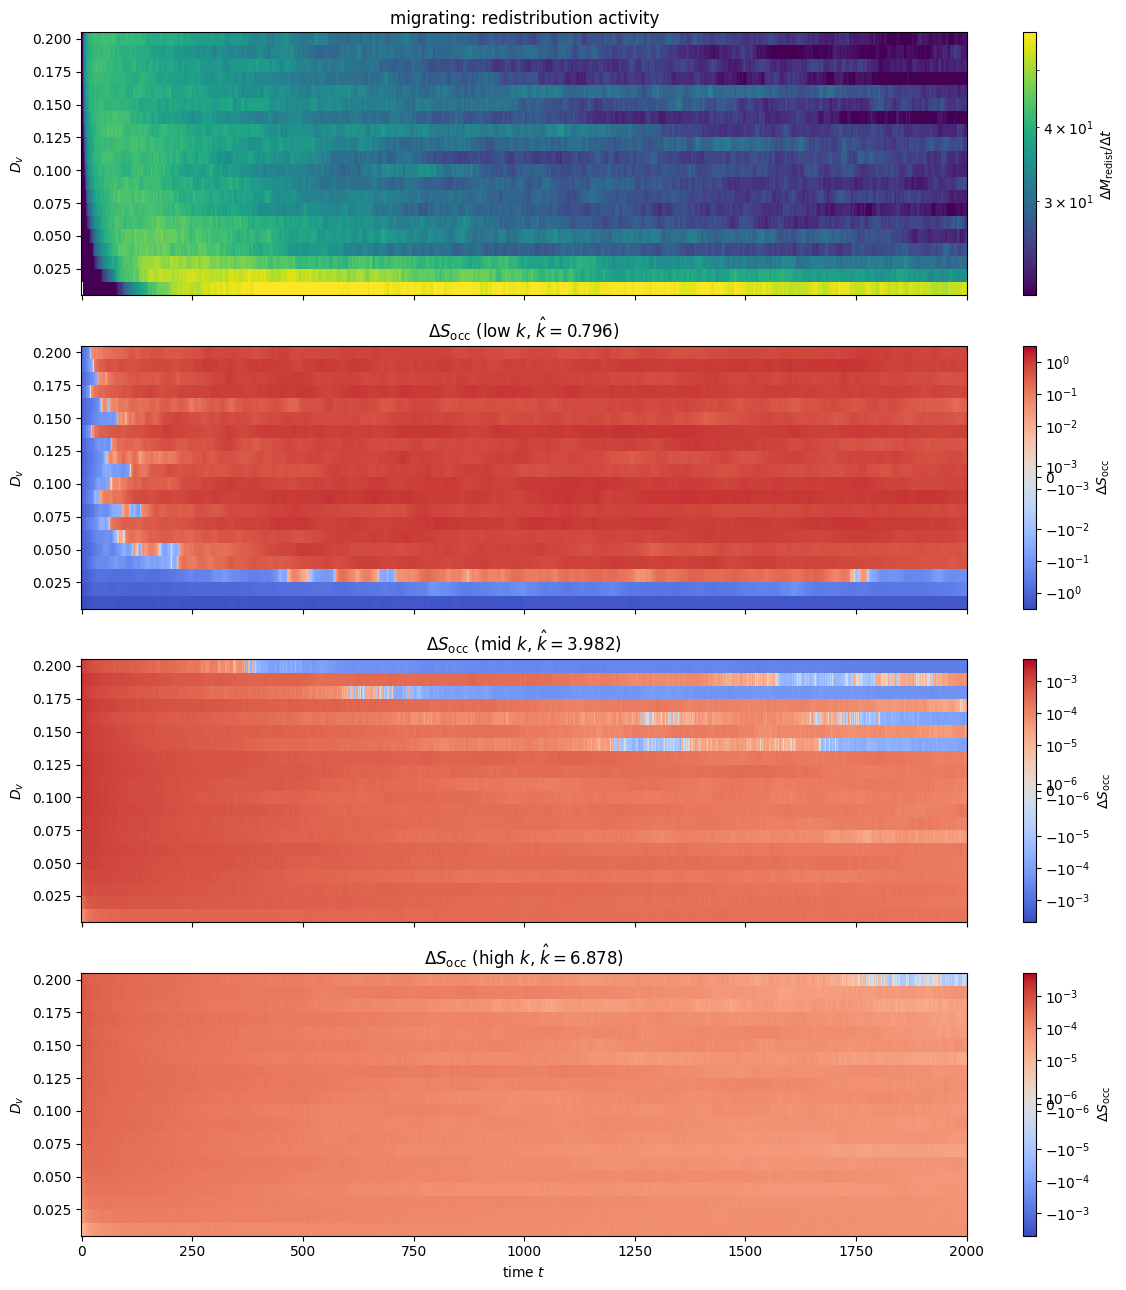

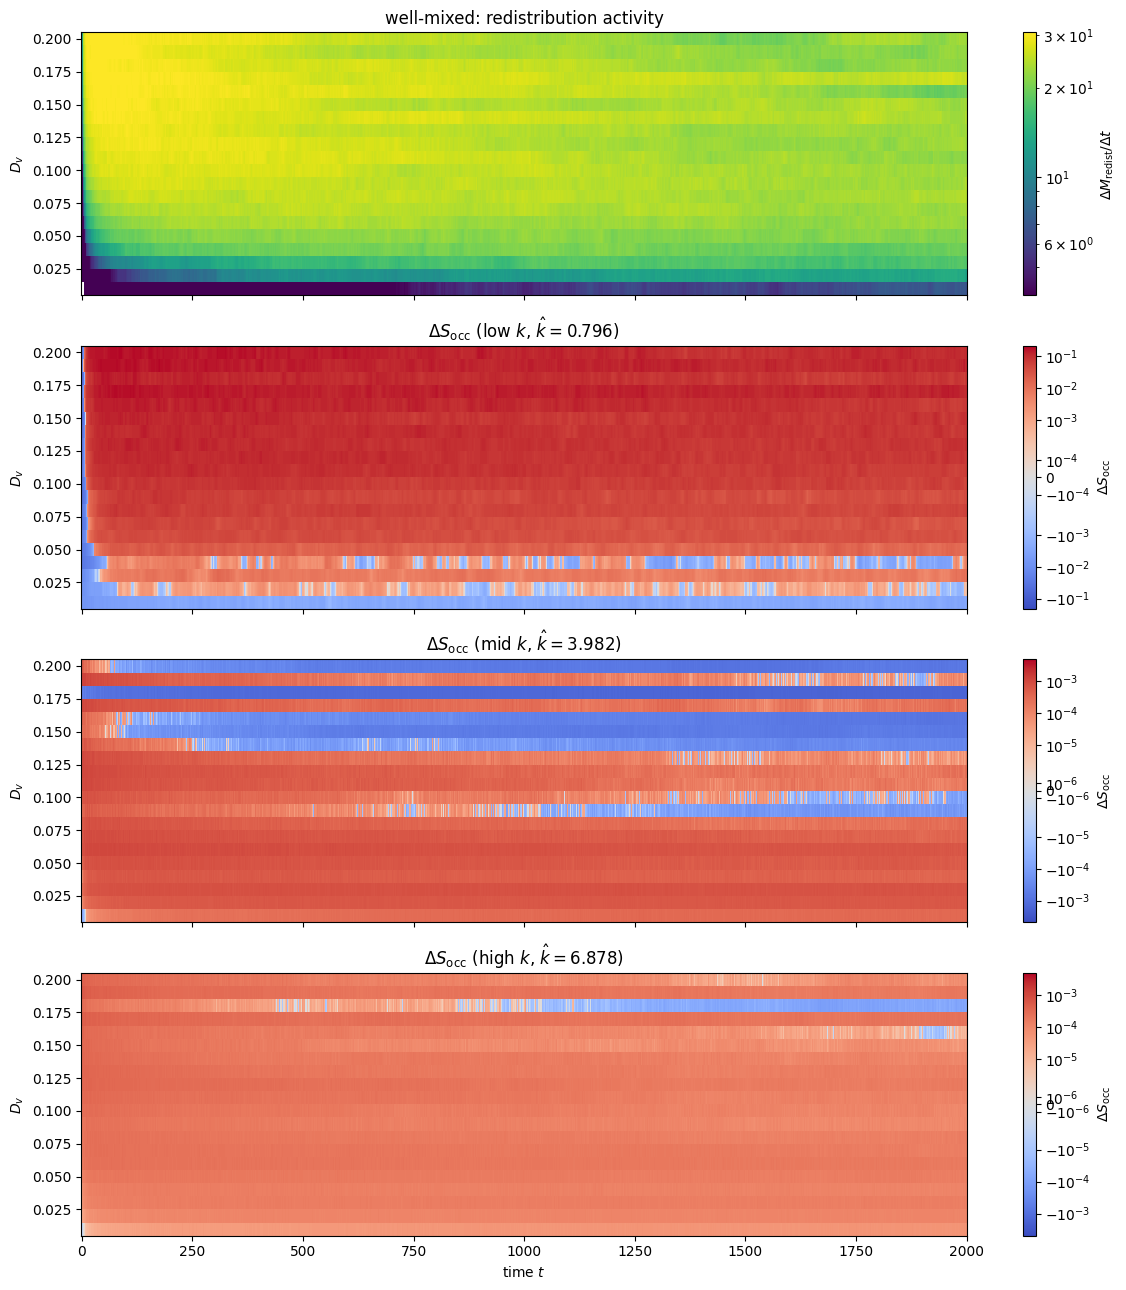

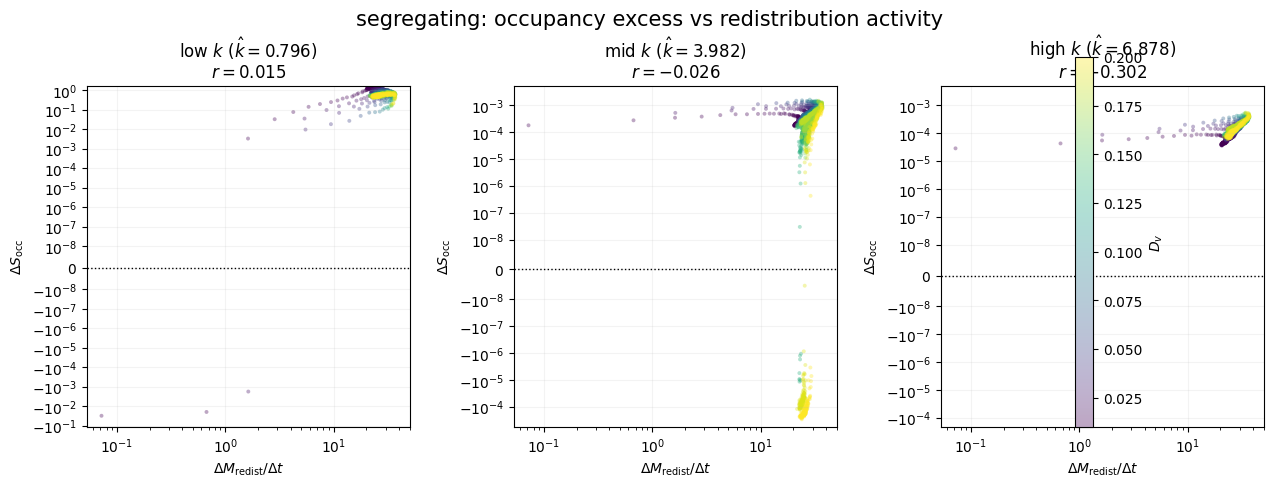

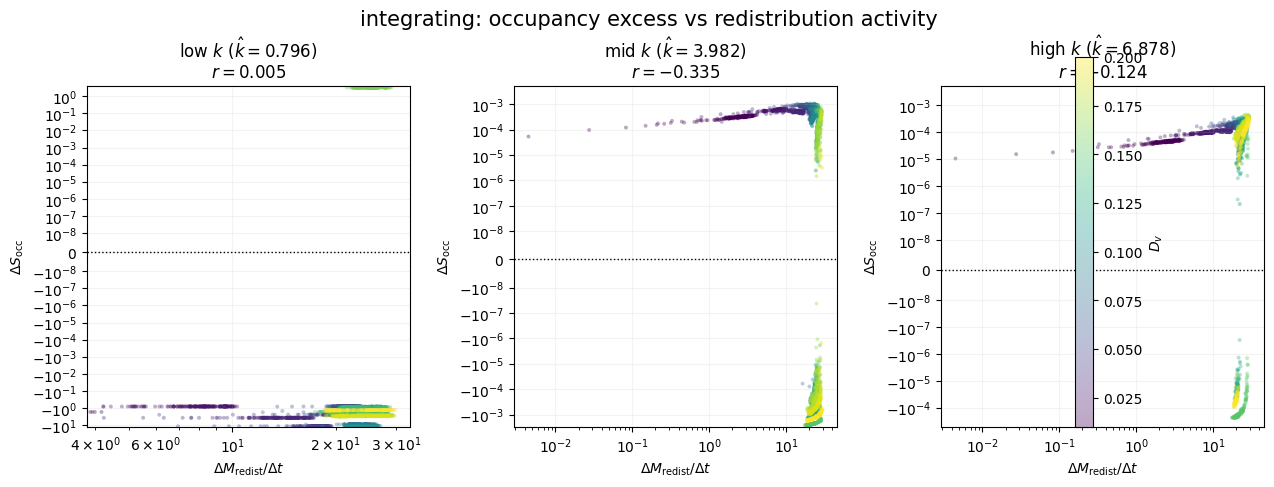

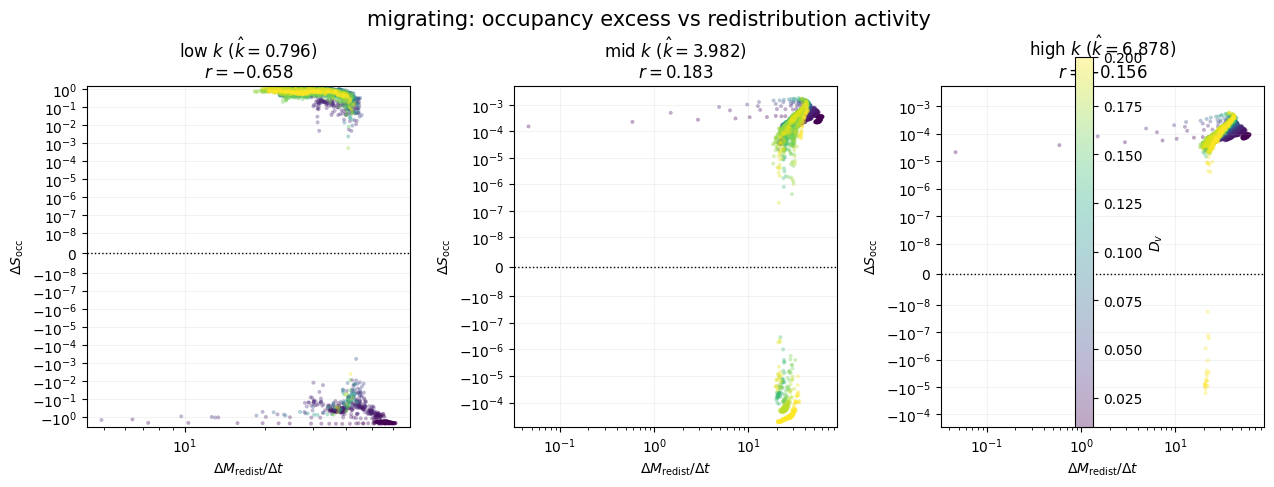

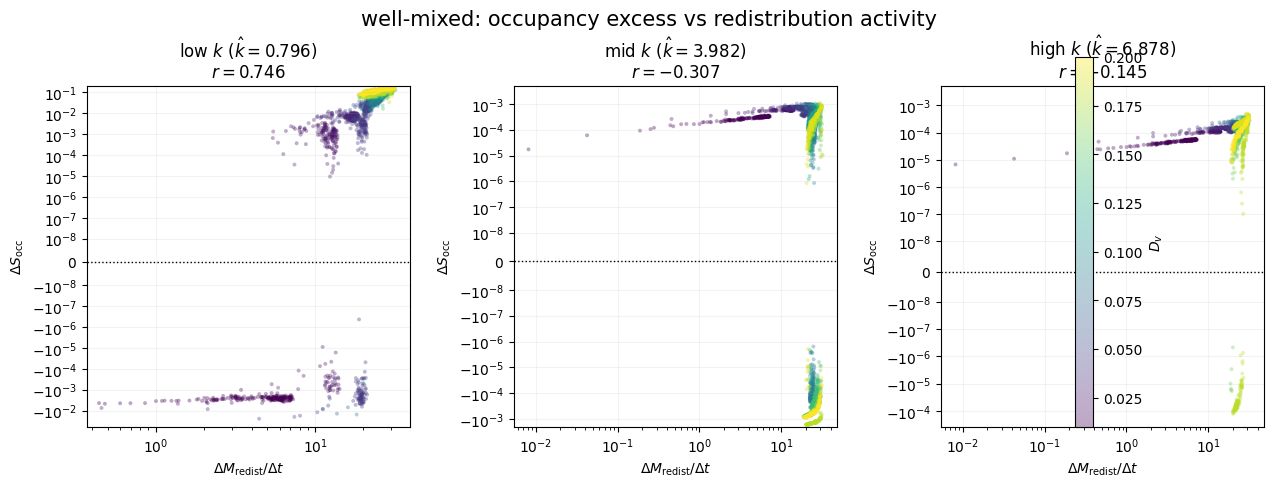

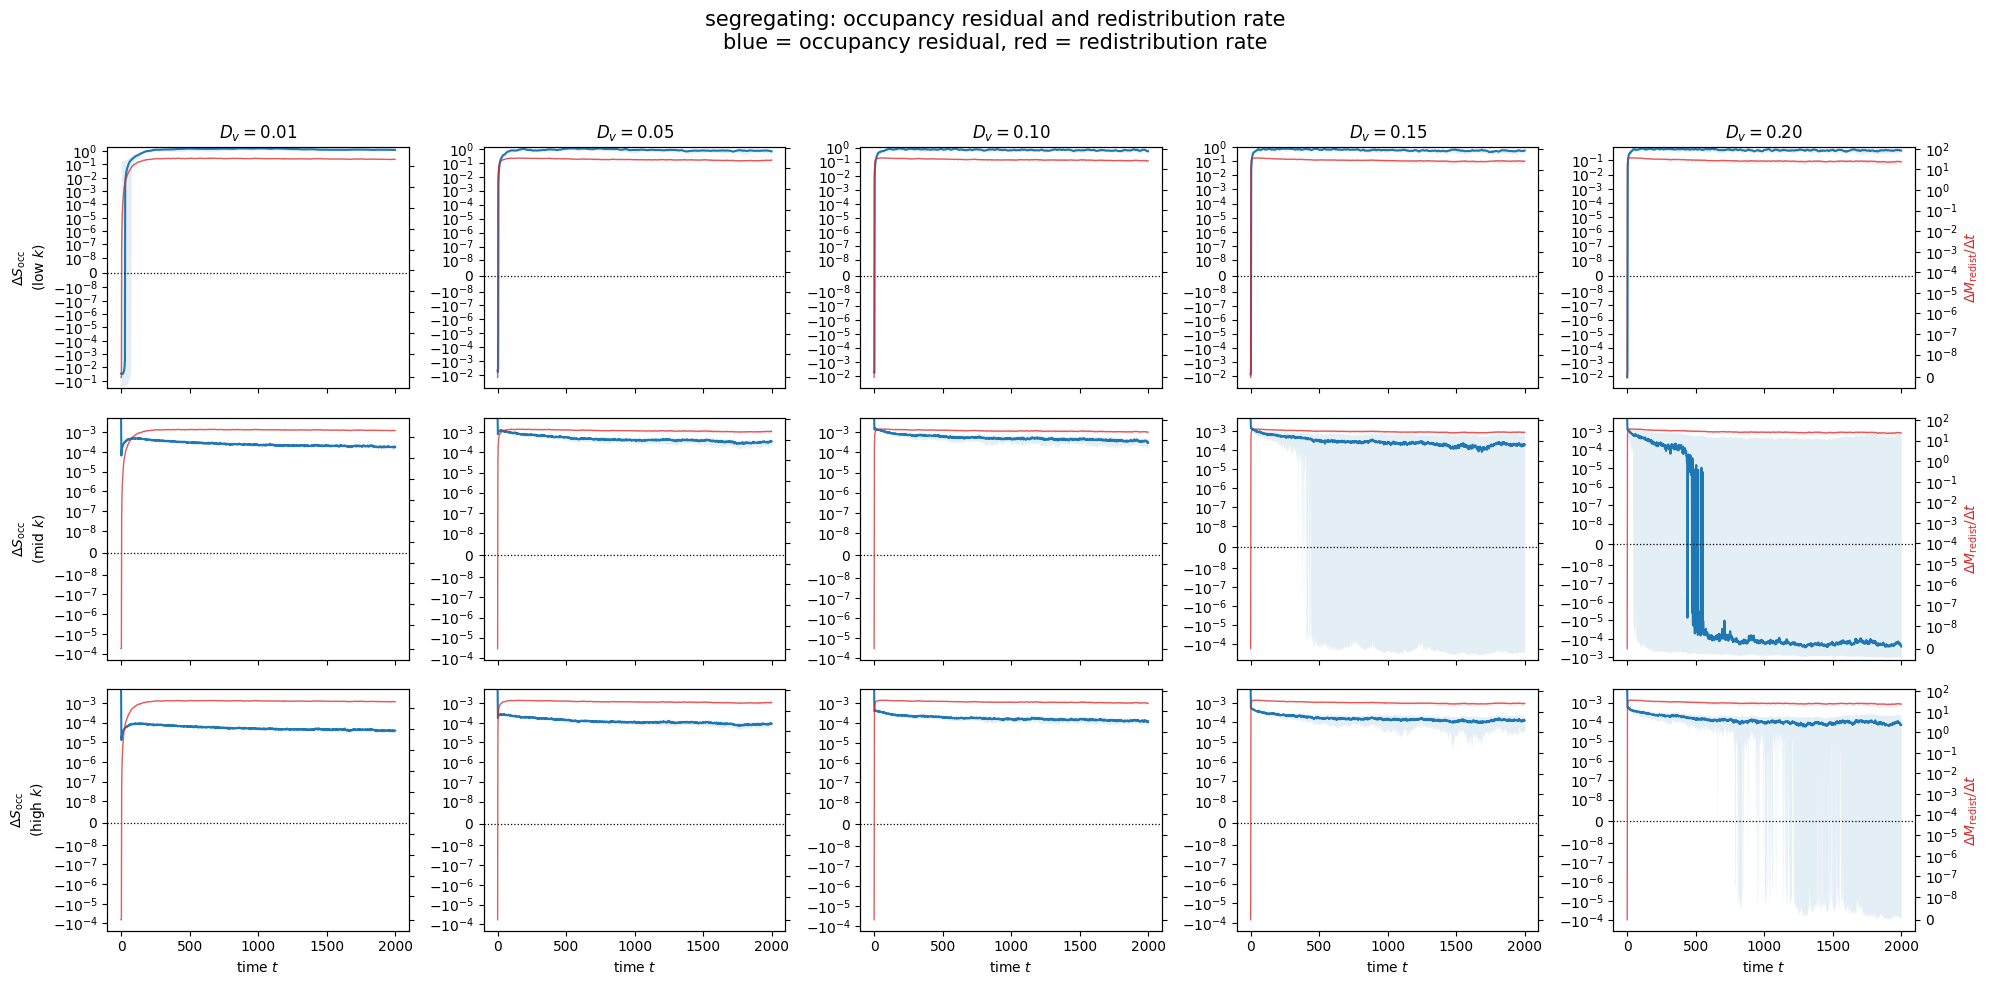

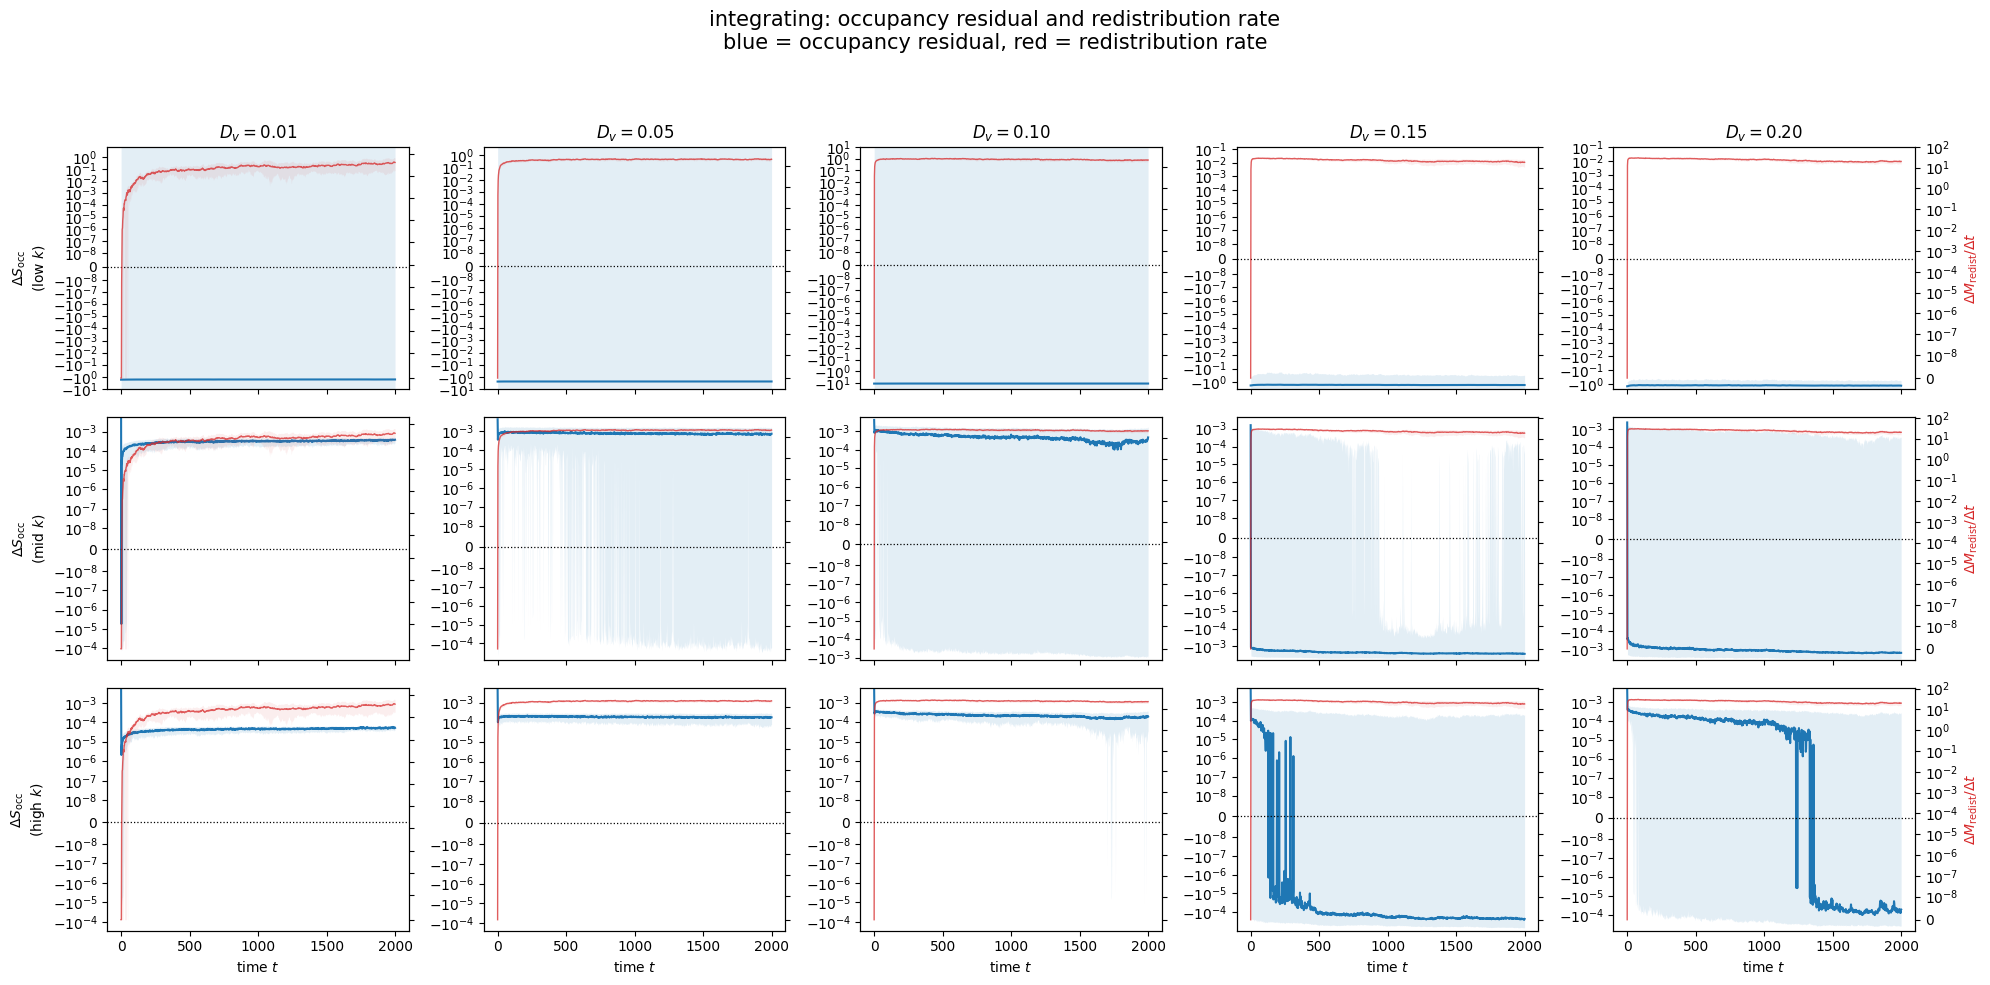

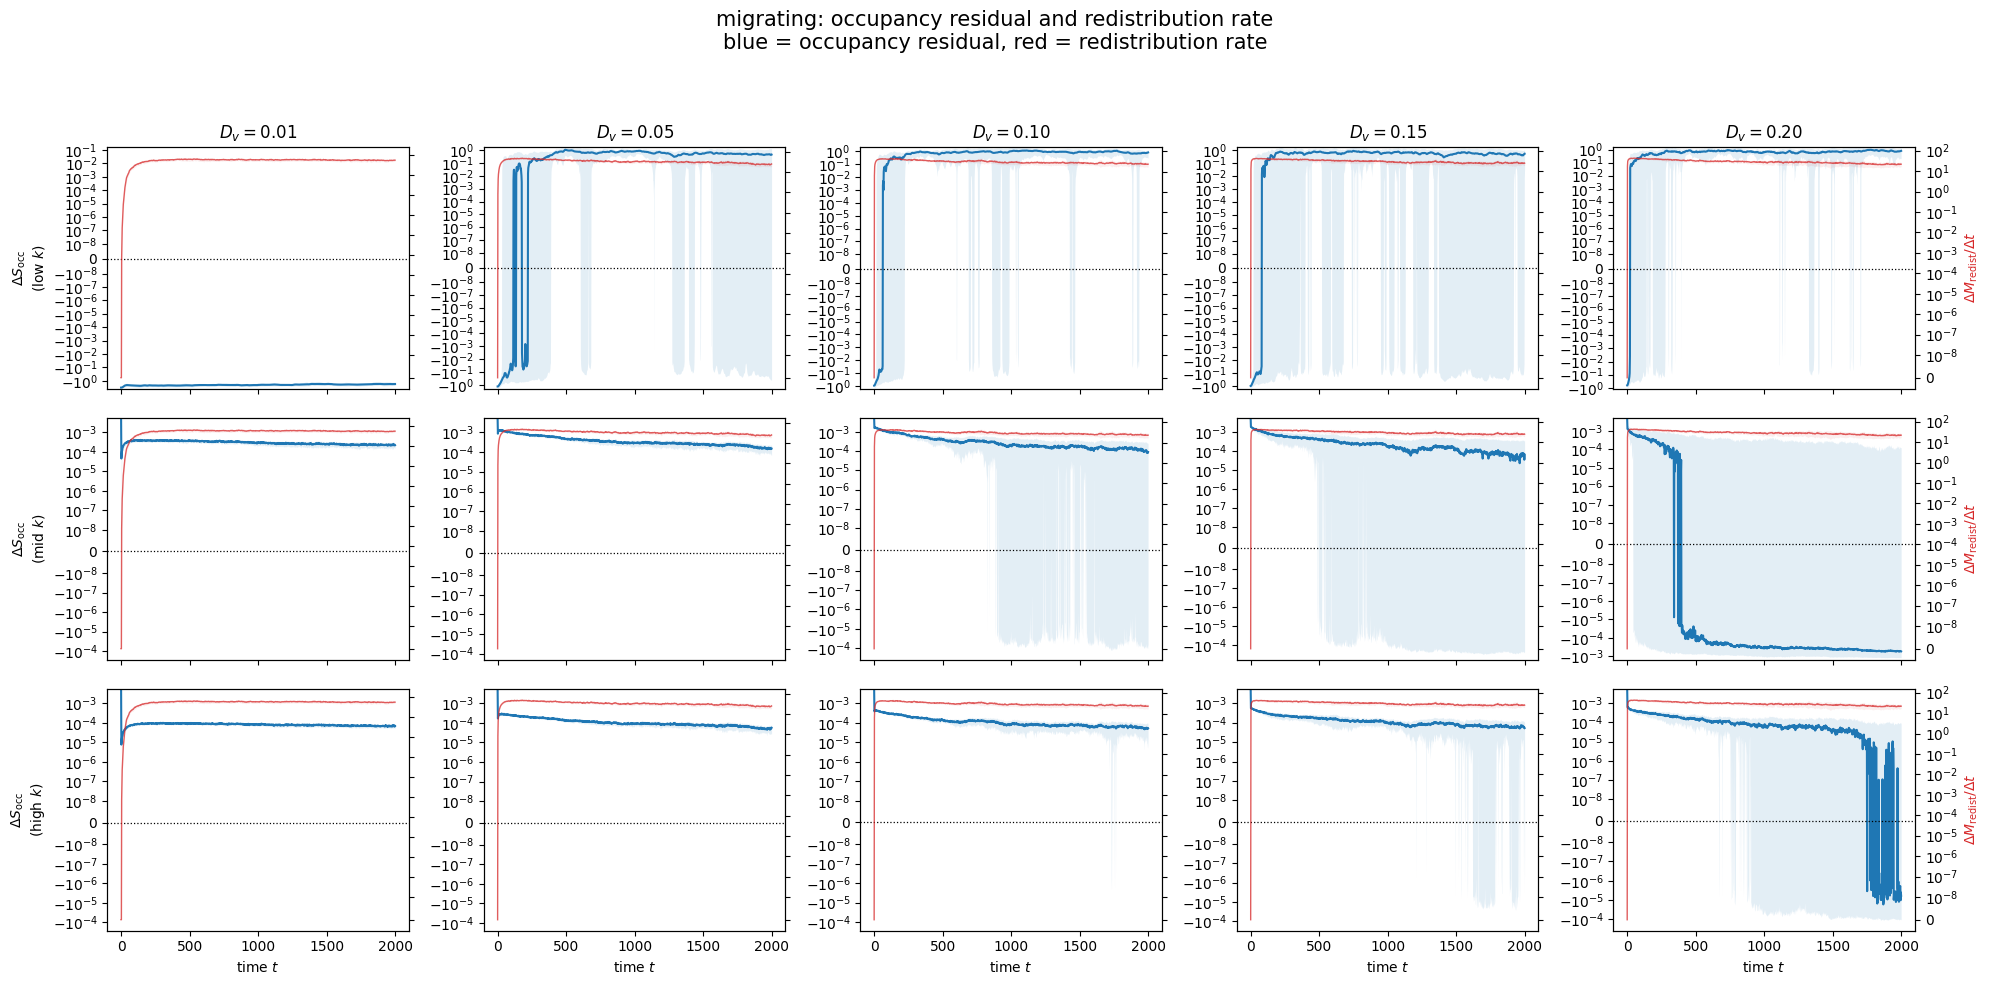

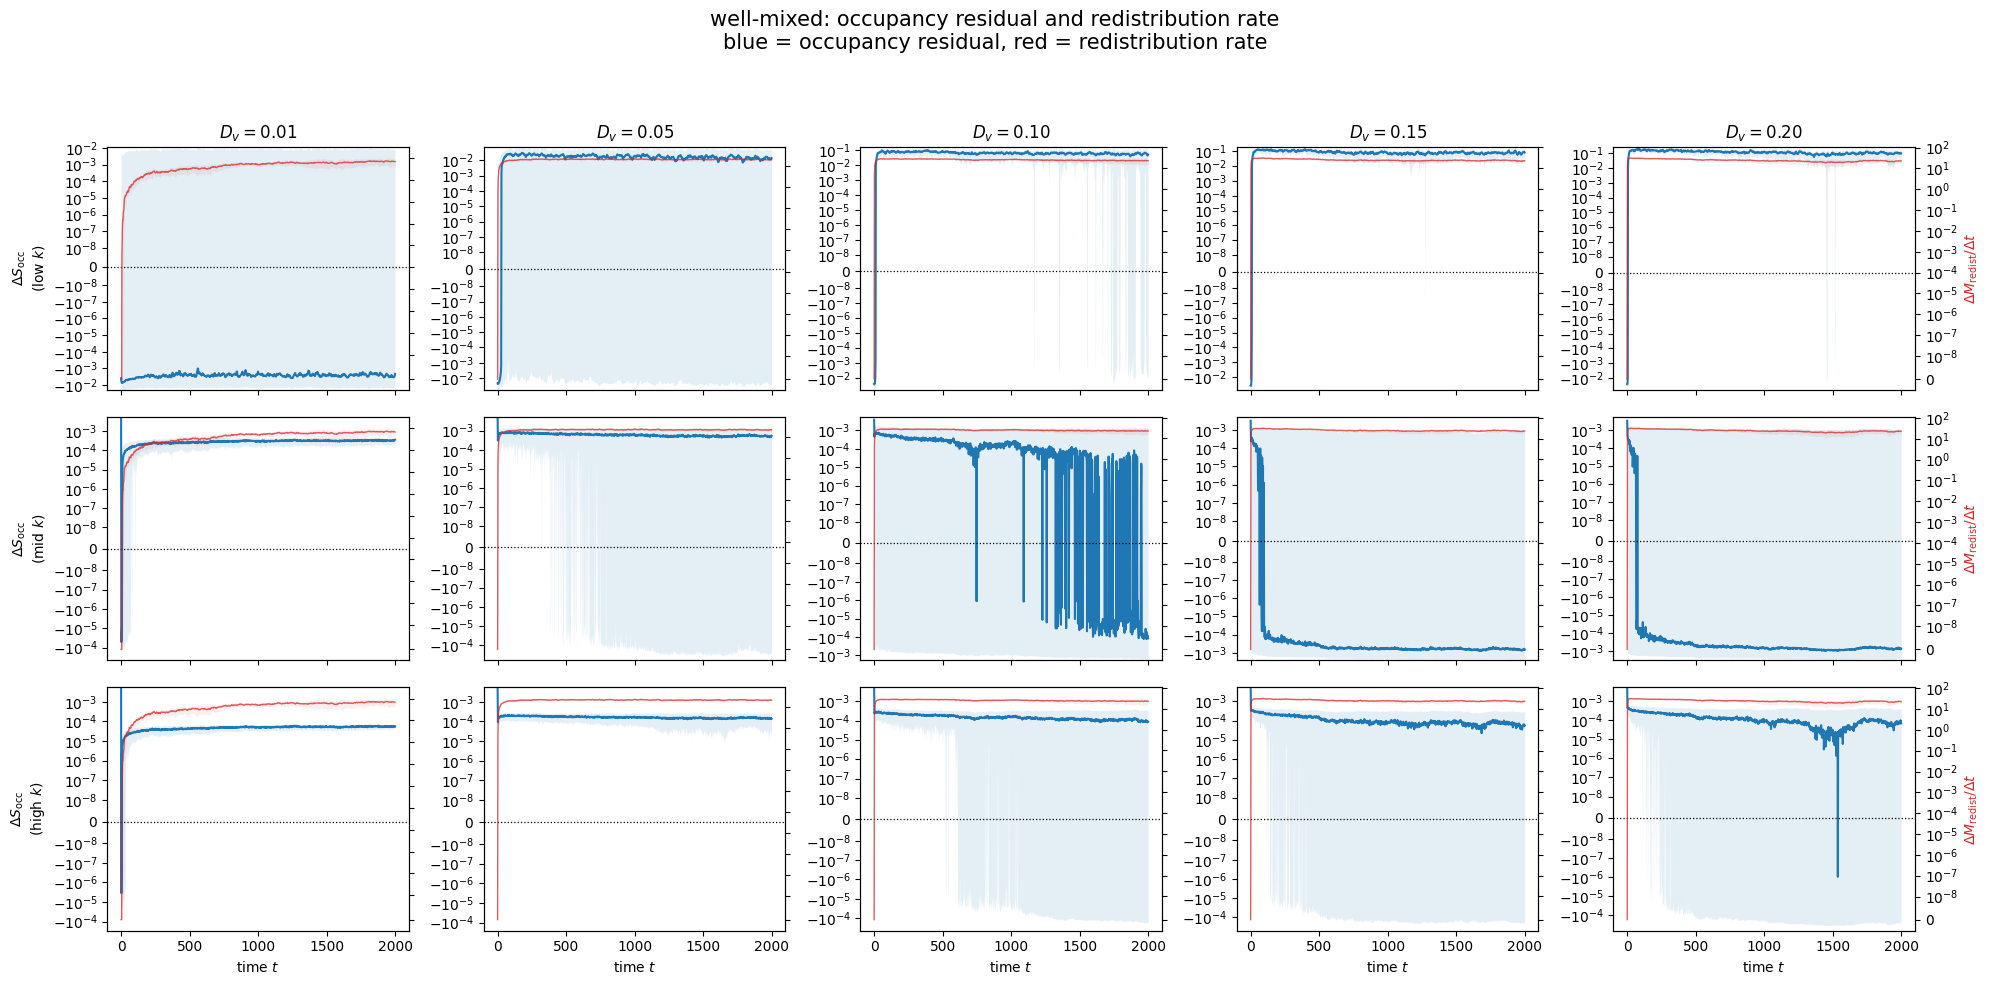



Summary correlations

segregating
  low  k (k=0.7964): r = -0.0448
  mid  k (k=3.9821): r = +0.3497
  high k (k=6.8782): r = +0.1275

integrating
  low  k (k=0.7964): r = +0.0049
  mid  k (k=3.9821): r = -0.2973
  high k (k=6.8782): r = +0.0961

migrating
  low  k (k=0.7964): r = -0.6949
  mid  k (k=3.9821): r = +0.4159
  high k (k=6.8782): r = +0.0895

well-mixed
  low  k (k=0.7964): r = +0.7442
  mid  k (k=3.9821): r = -0.2431
  high k (k=6.8782): r = +0.1145

Figures written to:
/home/wmrs@cbsp.nl/codebase/fluctuating_hydro/projection_vs_occupancy


In [39]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm, SymLogNorm
from fhd.structure_factor import structure_factor


# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = Path("data_snellius")

OUTPUT_DIR = Path("projection_vs_occupancy")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REGIMES = (
    "segregating",
    "integrating",
    "migrating",
    "well-mixed",
)

DV_VALUES = np.round(
    np.arange(0.01, 0.201, 0.01),
    2,
)

EXPECTED_NRUNS = 10

# -------------------------------------------------------------------------
# k bins
#
# None -> automatically choose:
#       low  = second-lowest useful radial bin
#       mid  = middle radial bin
#       high = second-highest radial bin
#
# Or explicitly give indices, e.g.
# K_BIN_INDICES = (2, 24, 47)
# -------------------------------------------------------------------------

K_BIN_INDICES = (5,27,47)

# D_v values for detailed time-series overlays.
TRACE_DV_VALUES = (
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
)


# Plotting controls
SCATTER_TIME_STRIDE = 5

SAVE_FIGURES = True
SHOW_FIGURES = True


# =============================================================================
# Projection-history keys
# =============================================================================

PROJECTION_KEYS = (
    "proj_hist_mass_redistributed_low_local",
    "proj_hist_mass_redistributed_low_global",
    "proj_hist_mass_redistributed_simplex_local",
    "proj_hist_mass_redistributed_simplex_global",
)


# =============================================================================
# Filename helpers
# =============================================================================

RUN_RE = re.compile(
    r"VS_run_(\d+)_Dv(\d+)_.*\.npz$"
)


def run_index_from_path(path):
    match = RUN_RE.match(path.name)

    if match is None:
        return -1

    return int(match.group(1))


def find_runs(regime, target_Dv):
    """
    Find all files belonging to one (regime, D_v) setting.
    """

    regime_dir = DATA_ROOT / regime

    if not regime_dir.exists():
        raise FileNotFoundError(
            f"Missing directory: {regime_dir}"
        )

    matches = []

    for path in sorted(
        regime_dir.glob("VS_run_*_Dv*_*.npz")
    ):
        with np.load(
            path,
            allow_pickle=False,
        ) as z:

            Dv_file = float(z["D_v"])

        if np.isclose(
            Dv_file,
            target_Dv,
            rtol=0.0,
            atol=1e-12,
        ):
            matches.append(path)

    if EXPECTED_NRUNS is not None:

        if len(matches) != EXPECTED_NRUNS:

            raise RuntimeError(
                f"{regime}, D_v={target_Dv}: "
                f"expected {EXPECTED_NRUNS} runs, "
                f"found {len(matches)}"
            )

    return matches


# =============================================================================
# Basic theory normalization
# =============================================================================

def fit_amplitude_logspace(theory, data):
    """
    Fit:

        data ~= amp * theory

    with one multiplicative amplitude in log-space.
    """

    theory = np.asarray(theory)
    data = np.asarray(data)

    valid = (
        np.isfinite(theory)
        & np.isfinite(data)
        & (theory > 0)
        & (data > 0)
    )

    if not np.any(valid):
        return 1.0

    return np.exp(
        np.mean(
            np.log(data[valid])
            - np.log(theory[valid])
        )
    )


def get_dynamic_fit_mask(
    k,
    S_AA,
    S_BB,
    S_AB,
    n_after_peak=2,
):
    """
    Same amplitude-fit region as in the previous spectrum plots.
    """

    k_mask = (
        np.isfinite(k)
        & (k > 0)
    )

    envelope = np.nanmax(
        np.vstack([
            np.where(
                k_mask,
                S_AA,
                np.nan,
            ),
            np.where(
                k_mask,
                S_BB,
                np.nan,
            ),
            np.where(
                k_mask,
                np.abs(S_AB),
                np.nan,
            ),
        ]),
        axis=0,
    )

    if np.all(np.isnan(envelope)):
        start = 1
    else:
        start = (
            np.nanargmax(envelope)
            + n_after_peak
        )

    idx = np.arange(len(k))

    mask = (
        k_mask
        & (idx >= start)
    )

    if np.sum(mask) < 3:

        mask = (
            k_mask
            & (
                idx
                >= max(
                    1,
                    start - n_after_peak,
                )
            )
        )

    return mask


# =============================================================================
# Projection history
# =============================================================================

def cumulative_projection_history(z):
    """
    Construct cumulative total redistributed mass from the SCHELLING
    projection stage only:

        M_redist =
            low local
          + low global
          + simplex local
          + simplex global.

    The stored history quantities are cumulative.
    """

    # -----------------------------------------------------------------
    # History time
    # -----------------------------------------------------------------

    if "proj_hist_time" in z.files:

        t_hist = (
            z["proj_hist_time"]
            .astype(float)
        )

    elif (
        "proj_hist_step" in z.files
        and "dt" in z.files
    ):

        t_hist = (
            z["proj_hist_step"].astype(float)
            * float(z["dt"])
        )

    else:

        raise KeyError(
            "No proj_hist_time or proj_hist_step found."
        )


    # -----------------------------------------------------------------
    # Restrict diagnostics to the Schelling projection call
    # -----------------------------------------------------------------

    if "proj_hist_stage" not in z.files:

        raise KeyError(
            "proj_hist_stage is missing from the NPZ."
        )

    stages = (
        z["proj_hist_stage"]
        .astype(str)
    )

    schelling_mask = (
        stages == "schelling"
    )

    if not np.any(schelling_mask):

        print(
            "Available projection stages:",
            np.unique(stages),
        )

        raise RuntimeError(
            "No projection-history entries with "
            "stage == 'schelling' found."
        )

    t_hist = t_hist[
        schelling_mask
    ]


    # -----------------------------------------------------------------
    # Sum four cumulative redistribution channels
    # -----------------------------------------------------------------

    histories = []

    for key in PROJECTION_KEYS:

        if key not in z.files:

            available = [
                k
                for k in z.files
                if k.startswith("proj_hist_")
            ]

            raise KeyError(
                f"Missing {key}\n\n"
                "Available projection-history keys:\n"
                + "\n".join(available)
            )

        values = (
            z[key]
            .astype(float)[schelling_mask]
        )

        histories.append(values)


    M_total = np.sum(
        histories,
        axis=0,
    )


    # -----------------------------------------------------------------
    # Sort chronologically
    # -----------------------------------------------------------------

    order = np.argsort(
        t_hist,
        kind="stable",
    )

    t_hist = t_hist[order]
    M_total = M_total[order]


    # -----------------------------------------------------------------
    # There should now normally be one Schelling diagnostic entry
    # per recorded step, but handle duplicate times defensively.
    #
    # Since these are CUMULATIVE values, keep the LAST snapshot.
    # -----------------------------------------------------------------

    unique_t, first_idx, counts = np.unique(
        t_hist,
        return_index=True,
        return_counts=True,
    )

    last_idx = (
        first_idx
        + counts
        - 1
    )

    t_hist = unique_t
    M_total = M_total[
        last_idx
    ]


    # -----------------------------------------------------------------
    # Sanity check: cumulative redistribution must be monotonic
    # -----------------------------------------------------------------

    dM = np.diff(
        M_total
    )

    tol = (
        1e-10
        * max(
            1.0,
            np.nanmax(
                np.abs(M_total)
            ),
        )
    )

    if np.any(dM < -tol):

        print(
            "WARNING: Schelling-stage cumulative "
            "redistribution history decreases."
        )


    return (
        t_hist,
        M_total,
    )


def projection_rate_on_frame_grid(
    z,
    frame_time,
):
    """
    Interpolate cumulative redistribution onto the saved-frame time grid,
    then finite-difference it.

    Returns
    -------
    M_frame : ndarray
        Cumulative redistributed mass at each saved frame.

    rate : ndarray
        Delta M / Delta t over each saved-frame interval.
        rate[i] corresponds approximately to the interval ending at t[i].
    """

    t_hist, M_hist = (
        cumulative_projection_history(z)
    )

    frame_time = np.asarray(
        frame_time,
        dtype=float,
    )

    # Before first diagnostic snapshot the accumulated mass is zero.
    M_frame = np.interp(
        frame_time,
        t_hist,
        M_hist,
        left=0.0,
        right=M_hist[-1],
    )

    rate = np.full(
        len(frame_time),
        np.nan,
        dtype=float,
    )

    dt = np.diff(
        frame_time
    )

    dM = np.diff(
        M_frame
    )

    rate[1:] = (
        dM / dt
    )

    # Define t=0 rate as zero rather than NaN.
    rate[0] = 0.0

    # Numerical interpolation noise can occasionally give tiny negatives.
    tiny_negative = (
        (rate < 0)
        & (
            np.abs(rate)
            < 1e-10
            * max(
                1.0,
                np.nanmax(
                    np.abs(rate)
                ),
            )
        )
    )

    rate[
        tiny_negative
    ] = 0.0

    return (
        M_frame,
        rate,
    )


# =============================================================================
# Theory
# =============================================================================

def theory_for_run(z):
    """
    Compute the stationary analytical spectrum for one run using its
    late-time mean densities, then apply the same common amplitude fit
    used in the spectrum figure.
    """

    k = z[
        "k_centers"
    ].copy()

    tail_idx = (
        z["tail_frame_indices"]
        .astype(int)
    )

    rhoA = float(
        np.mean(
            z["mean_A"][
                tail_idx
            ]
        )
    )

    rhoB = float(
        np.mean(
            z["mean_B"][
                tail_idx
            ]
        )
    )

    param = {
        "h": float(
            z["h"]
        ),
        "D": z[
            "D"
        ].copy(),
        "Gamma": z[
            "Gamma"
        ].copy(),
        "beta": float(
            z["beta"]
        ),
        "kappa": z[
            "kappa"
        ].copy(),
        "D_v": float(
            z["D_v"]
        ),
    }

    nk = len(k)

    S_AA = np.zeros(
        nk,
        dtype=float,
    )

    S_AB = np.zeros(
        nk,
        dtype=float,
    )

    S_BB = np.zeros(
        nk,
        dtype=float,
    )

    for i, kval in enumerate(k):

        S = structure_factor(
            kval,
            rhoA,
            rhoB,
            param,
        )

        S_AA[i] = np.real(
            S[0, 0]
        )

        S_AB[i] = np.real(
            S[0, 1]
        )

        S_BB[i] = np.real(
            S[1, 1]
        )


    # -----------------------------------------------------------------
    # Same common amplitude fit used previously
    # -----------------------------------------------------------------

    S_AA_data = z[
        "S_AA_tail_mean"
    ]

    S_BB_data = z[
        "S_BB_tail_mean"
    ]

    S_AB_data = z[
        "S_AB_tail_mean"
    ]

    fit_mask = get_dynamic_fit_mask(
        k,
        S_AA_data,
        S_BB_data,
        S_AB_data,
        n_after_peak=2,
    )

    theory_fit = np.vstack([
        S_AA[
            fit_mask
        ],
        S_BB[
            fit_mask
        ],
        np.abs(
            S_AB[
                fit_mask
            ]
        ),
    ])

    data_fit = np.vstack([
        S_AA_data[
            fit_mask
        ],
        S_BB_data[
            fit_mask
        ],
        np.abs(
            S_AB_data[
                fit_mask
            ]
        ),
    ])

    amp = fit_amplitude_logspace(
        theory_fit,
        data_fit,
    )


    # -----------------------------------------------------------------
    # Occupancy mode
    # -----------------------------------------------------------------

    S_occ = (
        S_AA
        + S_BB
        + 2.0 * S_AB
    )

    S_occ *= amp


    return {
        "k": k,
        "amp": amp,
        "S_occ": S_occ,
        "rhoA": rhoA,
        "rhoB": rhoB,
    }


# =============================================================================
# Determine common k bins
# =============================================================================

first_file = None

for regime in REGIMES:

    files = sorted(
        (
            DATA_ROOT
            / regime
        ).glob("VS_run_*_Dv*_*.npz")
    )

    if files:
        first_file = files[0]
        break


if first_file is None:

    raise FileNotFoundError(
        f"No NPZ files found under {DATA_ROOT}"
    )


with np.load(
    first_file,
    allow_pickle=False,
) as z:

    K_REFERENCE = (
        z["k_centers"]
        .copy()
    )


if K_BIN_INDICES is None:

    valid_k = np.where(
        np.isfinite(
            K_REFERENCE
        )
        & (
            K_REFERENCE > 0
        )
    )[0]

    # Avoid the very first and final radial bins.
    low_idx = valid_k[
        min(
            1,
            len(valid_k) - 1,
        )
    ]

    mid_idx = valid_k[
        len(valid_k) // 2
    ]

    high_idx = valid_k[
        max(
            0,
            len(valid_k) - 2,
        )
    ]

    K_INDICES = (
        low_idx,
        mid_idx,
        high_idx,
    )

else:

    K_INDICES = tuple(
        K_BIN_INDICES
    )


K_NAMES = (
    "low",
    "mid",
    "high",
)


print(
    "\nSelected k bins"
)

print(
    "=" * 60
)

for name, idx in zip(
    K_NAMES,
    K_INDICES,
):

    print(
        f"{name:4s}: "
        f"index={idx:2d}, "
        f"k={K_REFERENCE[idx]:.6f}"
    )


# =============================================================================
# Load one run
# =============================================================================

def analyze_run(path):
    """
    Compute:

        Delta S_occ(k,t)
            = S_occ_sim(k,t)
            - S_occ_theory(k)

    and:

        Delta M_redist / Delta t
    """

    with np.load(
        path,
        allow_pickle=False,
    ) as z:

        time = (
            z["time"]
            .astype(float)
        )

        k = (
            z["k_centers"]
            .astype(float)
        )

        if not np.allclose(
            k,
            K_REFERENCE,
            rtol=1e-12,
            atol=1e-14,
        ):

            raise RuntimeError(
                f"k-grid mismatch in {path}"
            )

        theory = (
            theory_for_run(z)
        )

        S_occ_sim = (
            z["S_occ"]
            .astype(float)
        )

        # shape:
        #     (ntime, 3)
        delta_S_occ = (
            S_occ_sim[
                :,
                K_INDICES,
            ]
            -
            theory["S_occ"][
                list(K_INDICES)
            ][None, :]
        )

        M_redist, rate = (
            projection_rate_on_frame_grid(
                z,
                time,
            )
        )

        return {
            "path": path,
            "run": run_index_from_path(
                path
            ),
            "time": time,
            "delta_S_occ": delta_S_occ,
            "rate": rate,
            "M_redist": M_redist,
            "amp": theory["amp"],
        }


# =============================================================================
# Load complete sweep
# =============================================================================

results = {
    regime: {}
    for regime in REGIMES
}


for regime in REGIMES:

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Loading {regime}"
    )

    print(
        "=" * 80
    )

    for Dv in DV_VALUES:

        paths = find_runs(
            regime,
            Dv,
        )

        run_results = [
            analyze_run(path)
            for path in paths
        ]

        # -------------------------------------------------------------
        # Verify common saved-frame grid
        # -------------------------------------------------------------

        time = (
            run_results[0][
                "time"
            ]
        )

        for run in run_results[1:]:

            if not np.allclose(
                run["time"],
                time,
            ):

                raise RuntimeError(
                    f"Time-grid mismatch for "
                    f"{regime}, D_v={Dv}"
                )

        # -------------------------------------------------------------
        # Stack independent realizations
        # -------------------------------------------------------------

        rate_runs = np.stack([
            run["rate"]
            for run in run_results
        ])

        delta_runs = np.stack([
            run["delta_S_occ"]
            for run in run_results
        ])

        M_runs = np.stack([
            run["M_redist"]
            for run in run_results
        ])

        # shapes:
        #
        # rate_runs  : (nruns, ntime)
        # delta_runs : (nruns, ntime, 3)

        results[
            regime
        ][float(Dv)] = {
            "time": time,

            "rate_runs":
                rate_runs,

            "delta_runs":
                delta_runs,

            "M_runs":
                M_runs,

            "rate_mean":
                np.mean(
                    rate_runs,
                    axis=0,
                ),

            "rate_std":
                np.std(
                    rate_runs,
                    axis=0,
                    ddof=1,
                ),

            "delta_mean":
                np.mean(
                    delta_runs,
                    axis=0,
                ),

            "delta_std":
                np.std(
                    delta_runs,
                    axis=0,
                    ddof=1,
                ),

            "M_mean":
                np.mean(
                    M_runs,
                    axis=0,
                ),
        }

        print(
            f"D_v={Dv:.2f}: "
            f"{len(run_results)} runs"
        )


# =============================================================================
# Utility for signed heatmaps
# =============================================================================

def signed_norm(data):
    """
    Symmetric logarithmic normalization about zero.
    """

    finite = np.asarray(
        data
    )

    finite = finite[
        np.isfinite(
            finite
        )
    ]

    if len(finite) == 0:

        return None

    vmax = np.max(
        np.abs(
            finite
        )
    )

    if vmax == 0:

        vmax = 1.0

    linthresh = max(
        1e-12,
        vmax * 1e-3,
    )

    return SymLogNorm(
        linthresh=linthresh,
        vmin=-vmax,
        vmax=vmax,
        base=10,
    )


# =============================================================================
# FIGURE 1:
# Heatmaps of redistribution rate and occupancy residual
# =============================================================================

for regime in REGIMES:

    time = results[
        regime
    ][float(DV_VALUES[0])][
        "time"
    ]

    rate_matrix = np.stack([
        results[
            regime
        ][float(Dv)][
            "rate_mean"
        ]
        for Dv in DV_VALUES
    ])

    # shape:
    #   (n_Dv, n_time, 3)
    delta_matrix = np.stack([
        results[
            regime
        ][float(Dv)][
            "delta_mean"
        ]
        for Dv in DV_VALUES
    ])


    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(12, 13),
        sharex=True,
    )


    # -----------------------------------------------------------------
    # Redistribution rate
    # -----------------------------------------------------------------

    ax = axes[0]

    positive_rate = (
        rate_matrix[
            np.isfinite(
                rate_matrix
            )
            & (
                rate_matrix > 0
            )
        ]
    )

    if len(positive_rate) > 0:

        # Avoid one enormous spike setting the full color scale.
        vmin = np.percentile(
            positive_rate,
            2,
        )

        vmax = np.percentile(
            positive_rate,
            99,
        )

        if vmin <= 0:
            vmin = np.min(
                positive_rate
            )

        rate_plot = np.ma.masked_less_equal(
            rate_matrix,
            0,
        )

        pcm = ax.pcolormesh(
            time,
            DV_VALUES,
            rate_plot,
            shading="auto",
            norm=LogNorm(
                vmin=vmin,
                vmax=vmax,
            ),
            cmap="viridis",
        )

    else:

        pcm = ax.pcolormesh(
            time,
            DV_VALUES,
            rate_matrix,
            shading="auto",
            cmap="viridis",
        )

    cbar = fig.colorbar(
        pcm,
        ax=ax,
    )

    cbar.set_label(
        r"$\Delta M_{\rm redist}/\Delta t$"
    )

    ax.set_ylabel(
        r"$D_v$"
    )

    ax.set_title(
        f"{regime}: redistribution activity"
    )


    # -----------------------------------------------------------------
    # Occupancy residuals
    # -----------------------------------------------------------------

    for j, (
        name,
        k_idx,
    ) in enumerate(
        zip(
            K_NAMES,
            K_INDICES,
        )
    ):

        ax = axes[
            j + 1
        ]

        data = (
            delta_matrix[
                :,
                :,
                j,
            ]
        )

        pcm = ax.pcolormesh(
            time,
            DV_VALUES,
            data,
            shading="auto",
            norm=signed_norm(
                data
            ),
            cmap="coolwarm",
        )

        cbar = fig.colorbar(
            pcm,
            ax=ax,
        )

        cbar.set_label(
            r"$\Delta S_{\rm occ}$"
        )

        ax.set_ylabel(
            r"$D_v$"
        )

        ax.set_title(
            fr"$\Delta S_{{\rm occ}}$ "
            fr"({name} $k$, "
            fr"$\hat{{k}}={K_REFERENCE[k_idx]:.3f}$)"
        )


    axes[-1].set_xlabel(
        r"time $t$"
    )

    fig.tight_layout()

    if SAVE_FIGURES:

        fig.savefig(
            OUTPUT_DIR
            / f"{regime}_heatmaps.png",
            dpi=200,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# =============================================================================
# FIGURE 2:
# Direct Delta S_occ vs redistribution rate
#
# Each point is one ensemble-averaged saved time.
# Color indicates D_v.
# =============================================================================

for regime in REGIMES:

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(15, 4.8),
    )

    last_scatter = None

    for j, (
        name,
        k_idx,
    ) in enumerate(
        zip(
            K_NAMES,
            K_INDICES,
        )
    ):

        ax = axes[j]

        x_all = []
        y_all = []

        for Dv in DV_VALUES:

            entry = results[
                regime
            ][float(Dv)]

            rate = (
                entry[
                    "rate_mean"
                ][
                    ::SCATTER_TIME_STRIDE
                ]
            )

            delta = (
                entry[
                    "delta_mean"
                ][
                    ::SCATTER_TIME_STRIDE,
                    j,
                ]
            )

            valid = (
                np.isfinite(
                    rate
                )
                & np.isfinite(
                    delta
                )
            )

            rate = rate[
                valid
            ]

            delta = delta[
                valid
            ]

            last_scatter = ax.scatter(
                rate,
                delta,
                c=np.full(
                    len(rate),
                    Dv,
                ),
                cmap="viridis",
                vmin=DV_VALUES.min(),
                vmax=DV_VALUES.max(),
                s=8,
                alpha=0.35,
                edgecolors="none",
            )

            x_all.append(
                rate
            )

            y_all.append(
                delta
            )


        # -------------------------------------------------------------
        # Descriptive Pearson correlation.
        #
        # This is NOT an independent-sample significance test because
        # successive times are autocorrelated.
        # -------------------------------------------------------------

        x_all = np.concatenate(
            x_all
        )

        y_all = np.concatenate(
            y_all
        )

        valid_corr = (
            np.isfinite(
                x_all
            )
            & np.isfinite(
                y_all
            )
        )

        if np.sum(
            valid_corr
        ) > 2:

            r = np.corrcoef(
                x_all[
                    valid_corr
                ],
                y_all[
                    valid_corr
                ],
            )[0, 1]

        else:

            r = np.nan


        ax.axhline(
            0.0,
            color="black",
            linestyle=":",
            linewidth=1.0,
        )

        ax.set_xscale(
            "log",
        )

        ax.set_yscale(
            "symlog",
            linthresh=1e-8,
        )

        ax.set_xlabel(
            r"$\Delta M_{\rm redist}/\Delta t$"
        )

        ax.set_ylabel(
            r"$\Delta S_{\rm occ}$"
        )

        ax.set_title(
            fr"{name} $k$ "
            fr"($\hat{{k}}={K_REFERENCE[k_idx]:.3f}$)"
            "\n"
            fr"$r={r:.3f}$"
        )

        ax.grid(
            alpha=0.15,
        )


    if last_scatter is not None:

        cbar = fig.colorbar(
            last_scatter,
            ax=axes,
            pad=0.02,
        )

        cbar.set_label(
            r"$D_v$"
        )


    fig.suptitle(
        f"{regime}: occupancy excess vs redistribution activity",
        fontsize=15,
    )

    fig.subplots_adjust(
        top=0.82,
        right=0.91,
        wspace=0.32,
    )

    if SAVE_FIGURES:

        fig.savefig(
            OUTPUT_DIR
            / f"{regime}_scatter.png",
            dpi=200,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# =============================================================================
# FIGURE 3:
# Detailed time traces for selected D_v values.
#
# Blue:
#     Delta S_occ
#
# Red:
#     redistribution rate
#
# Rows:
#     low / mid / high k
#
# Columns:
#     selected D_v values
# =============================================================================

for regime in REGIMES:

    fig, axes = plt.subplots(
        nrows=3,
        ncols=len(
            TRACE_DV_VALUES
        ),
        figsize=(
            4.0
            * len(
                TRACE_DV_VALUES
            ),
            10,
        ),
        sharex="col",
    )


    for col, Dv in enumerate(
        TRACE_DV_VALUES
    ):

        entry = results[
            regime
        ][float(Dv)]

        time = entry[
            "time"
        ]

        rate_mean = entry[
            "rate_mean"
        ]

        rate_std = entry[
            "rate_std"
        ]


        for row, (
            name,
            k_idx,
        ) in enumerate(
            zip(
                K_NAMES,
                K_INDICES,
            )
        ):

            ax = axes[
                row,
                col,
            ]

            ax2 = ax.twinx()


            # ---------------------------------------------------------
            # Occupancy residual
            # ---------------------------------------------------------

            delta_mean = (
                entry[
                    "delta_mean"
                ][
                    :,
                    row,
                ]
            )

            delta_std = (
                entry[
                    "delta_std"
                ][
                    :,
                    row,
                ]
            )

            ax.plot(
                time,
                delta_mean,
                color="tab:blue",
                linewidth=1.5,
            )

            ax.fill_between(
                time,
                delta_mean
                - delta_std,
                delta_mean
                + delta_std,
                color="tab:blue",
                alpha=0.12,
                linewidth=0,
            )

            ax.axhline(
                0.0,
                color="black",
                linestyle=":",
                linewidth=0.9,
            )


            # ---------------------------------------------------------
            # Redistribution rate
            # ---------------------------------------------------------

            ax2.plot(
                time,
                rate_mean,
                color="tab:red",
                linewidth=1.0,
                alpha=0.75,
            )

            lower_rate = np.maximum(
                rate_mean
                - rate_std,
                0.0,
            )

            ax2.fill_between(
                time,
                lower_rate,
                rate_mean
                + rate_std,
                color="tab:red",
                alpha=0.08,
                linewidth=0,
            )


            # ---------------------------------------------------------
            # Scales
            # ---------------------------------------------------------

            ax.set_yscale(
                "symlog",
                linthresh=1e-8,
            )

            ax2.set_yscale(
                "symlog",
                linthresh=1e-8,
            )


            # ---------------------------------------------------------
            # Labels
            # ---------------------------------------------------------

            if row == 0:

                ax.set_title(
                    fr"$D_v={Dv:.2f}$"
                )

            if col == 0:

                ax.set_ylabel(
                    fr"$\Delta S_{{\rm occ}}$"
                    "\n"
                    fr"({name} $k$)"
                )

            if col == (
                len(
                    TRACE_DV_VALUES
                )
                - 1
            ):

                ax2.set_ylabel(
                    r"$\Delta M_{\rm redist}/\Delta t$",
                    color="tab:red",
                )

            else:

                ax2.set_yticklabels(
                    []
                )

            if row == 2:

                ax.set_xlabel(
                    r"time $t$"
                )


    fig.suptitle(
        f"{regime}: occupancy residual and redistribution rate\n"
        "blue = occupancy residual, red = redistribution rate",
        fontsize=15,
    )

    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.94,
        ]
    )

    if SAVE_FIGURES:

        fig.savefig(
            OUTPUT_DIR
            / f"{regime}_time_traces.png",
            dpi=200,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# =============================================================================
# Simple numerical summary
# =============================================================================

print(
    "\n\nSummary correlations"
)

print(
    "=" * 90
)

for regime in REGIMES:

    print(
        f"\n{regime}"
    )

    for j, (
        name,
        k_idx,
    ) in enumerate(
        zip(
            K_NAMES,
            K_INDICES,
        )
    ):

        x = []
        y = []

        for Dv in DV_VALUES:

            entry = results[
                regime
            ][float(Dv)]

            x.append(
                entry[
                    "rate_mean"
                ]
            )

            y.append(
                entry[
                    "delta_mean"
                ][
                    :,
                    j,
                ]
            )

        x = np.concatenate(
            x
        )

        y = np.concatenate(
            y
        )

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
        )

        r = np.corrcoef(
            x[valid],
            y[valid],
        )[0, 1]

        print(
            f"  {name:4s} k "
            f"(k={K_REFERENCE[k_idx]:.4f}): "
            f"r = {r:+.4f}"
        )


print(
    "\nFigures written to:"
)

print(
    OUTPUT_DIR.resolve()
)